# Weather Data Retrieval Testing

The purpose of this notebook is to test the outputs of the weather data retrieval module to ensure data is in the correct format, and retrieved as requested.

### Importing Libraries

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
from pathlib import Path
import zipfile
import magic
import polars as pl
import pandas as pd
import numpy as np

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import imageio.v2 as iio


### Helper Functions

In [76]:
def show_dir_contents(path='.'):
    """List contents of current directory"""
    base = Path(path).resolve()
    print("Contents of current directory:")
    for p in base.rglob('*'):
        print("  -> " + str(p.relative_to(base)))

In [77]:
def print_directory_tree(start_path='.', show_files=False):
    """Print directory tree similar to 'tree' command"""
    for root, dirs, files in os.walk(start_path):
        # Calculate indentation
        level = root.replace(start_path, '').count(os.sep)
        indent = '│   ' * level

        if root == start_path:
            print(f"📁 {os.path.basename(root) or '.'}")
        else:
            print(f"{indent}└── 📁 {os.path.basename(root)}")

        subindent = '│   ' * (level + 1)

        if show_files:
            for f in sorted(files):
                print(f"{subindent}└── 📄 {f}")

In [78]:
def get_mime_type(path):
    """Get MIME type of file using python-magic"""
    m = magic.Magic(mime=True)
    return m.from_file(path)


In [79]:
def read_magic(path, n=8):
    """Read first n bytes of file to determine MIME type"""
    with open(path, 'rb') as f:
        return f.read(n)

In [80]:
def is_grib(path):
    """Check if file is GRIB by reading first 4 bytes"""
    try:
        with open(path, 'rb') as f:
            return f.read(4) == b'GRIB'
    except OSError:
        return False

In [81]:
def is_zip(path):
    """Check if file is ZIP by using zipfile module"""
    return zipfile.is_zipfile(path)

In [82]:
def testing_filepaths(path):
    print(f"Testing filepath for [{os.path.basename(path)}]:")
    print(f"  - MIME type: {get_mime_type(path)}")
    print(f"  - Magic bytes: {read_magic(path)}")

#### Visualisations

In [112]:
def plot_day_polars_direct(df, date, column):
    """
    Plot directly from Polars without pandas conversion
    """
    # Ensure timestamp is datetime and filter
    df = df.with_columns(pl.col('time').cast(pl.Datetime))
    target_date = pd.to_datetime(date).date()
    day_data = df.filter(pl.col('time').dt.date() == target_date)

    # Extract data as numpy arrays
    timestamps = day_data['time'].to_numpy()
    values = day_data[column].to_numpy()

    plt.figure(figsize=(12, 5))
    plt.plot(timestamps, values, marker='o', linestyle='-', markersize=3)
    plt.title(f'{column.replace("_", " ").title()} on {date}')
    plt.xlabel('Time')
    plt.ylabel(column.replace('_', ' ').title())
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return day_data


### Defining Filepaths

#### Checking Directory Structure

In [83]:
!pwd

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/notebooks


In [84]:
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)

print_directory_tree(start_path=base_dir, show_files=False)

📁 open-source-marginal-emissions.nosync
│   └── 📁 weather_data_processing
│   └── 📁 information
│   └── 📁 logs
│   │   └── 📁 weather_data_processing
│   │   └── 📁 weather_processing
│   │   └── 📁 weather_data_retrieval
│   │   └── 📁 grid_data_processing
│   │   └── 📁 grid_data_retrieval
│   └── 📁 configs
│   │   └── 📁 weather_data_processing
│   │   └── 📁 grid_data_processing
│   │   └── 📁 weather
│   │   └── 📁 grid
│   └── 📁 packages
│   │   └── 📁 osme_common
│   │   │   └── 📁 tests
│   │   │   └── 📁 docs
│   │   │   └── 📁 src
│   │   │   │   └── 📁 osme_common
│   │   │   │   │   └── 📁 __pycache__
│   │   │   │   └── 📁 osme_common.egg-info
│   │   └── 📁 weather_data_processing
│   │   │   └── 📁 tests
│   │   │   └── 📁 docs
│   │   │   └── 📁 src
│   │   │   │   └── 📁 weather_data_processing.egg-info
│   │   │   │   └── 📁 weather_data_processing
│   │   │   │   │   └── 📁 pipeline
│   │   │   │   │   │   └── 📁 __pycache__
│   │   │   │   │   └── 📁 processing
│   │   │   │   │   │   └── 📁

In [85]:
data_dir = base_dir + "/data/"
show_dir_contents(data_dir)
era5_world_dir = data_dir + "era5-world/"

Contents of current directory:
  -> .DS_Store
  -> README.md
  -> grid_data
  -> geoBoundaries
  -> era5-world
  -> era5-land
  -> grid_data/.DS_Store
  -> grid_data/processed
  -> grid_data/raw
  -> grid_data/processed/.DS_Store
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step2_half-hourly.parquet
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step3_final.parquet
  -> grid_data/processed/carbontracker_grid-data_2018-11_2026-02_step1_gapfilled.parquet
  -> grid_data/processed/gap_filling_checkpoints
  -> grid_data/processed/gap_filling_checkpoints/.DS_Store
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step03_linear_40min.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step04_gradient_pass2.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step01_linear_80min.parquet
  -> grid_data/processed/gap_filling_checkpoints/checkpoint_step02_gradient_pass1.parquet
  -> grid_data/raw/.DS_Store
  -> grid_da

#### Defining GeoFilepaths

In [86]:
geoboundaries_folder = data_dir + "geoBoundaries/"
show_dir_contents(geoboundaries_folder)

Contents of current directory:
  -> geoBoundariesCGAZ_ADM1.zip
  -> geoBoundariesCGAZ_ADM0.zip
  -> geoBoundariesCGAZ_ADM2.zip
  -> .DS_Store
  -> images
  -> extracted
  -> masks
  -> images/.DS_Store
  -> images/era5-world_INDIA_mask_overview.png
  -> images/era5-world_INDIA_mask_combined0.9_59b010b0_detail.png
  -> images/era5-world_INDIA_mask_centroid_916d3fbb_detail.png
  -> images/era5-world_INDIA_mask_combined0.8_b6b709f9_detail.png
  -> images/era5-world_INDIA_mask_intersection_66c055b4_detail.png
  -> extracted/India.geojson
  -> masks/.DS_Store
  -> masks/era5-world_INDIA_mask_intersection_66c055b4.parquet
  -> masks/mask_metadata
  -> masks/era5-world_INDIA_mask_combined0.9_59b010b0.parquet
  -> masks/era5-world_INDIA_mask_centroid_916d3fbb.parquet
  -> masks/era5-world_INDIA_mask_combined0.8_b6b709f9.parquet
  -> masks/mask_metadata/era5-world_INDIA_mask_intersection_66c055b4.json
  -> masks/mask_metadata/era5-world_INDIA_mask_combined0.8_b6b709f9.json
  -> masks/mask_metad

In [87]:
adm0_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM0.zip')
adm1_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM1.zip')
adm2_path = Path(geoboundaries_folder,'geoBoundariesCGAZ_ADM2.zip')

overview_png_path = Path(geoboundaries_folder,'images/era5-world_INDIA_mask_overview.png')
centroid_detail_png_path = Path(geoboundaries_folder,'images/era5-world_INDIA_mask_centroid_916d3fbb_detail.png')

In [88]:
print(overview_png_path)

/Users/Daniel/Desktop/open-source-marginal-emissions.nosync/data/geoBoundaries/images/era5-world_INDIA_mask_overview.png


#### Defining Data Filepaths

In [89]:
step0_raw_data_2018_01_path = Path(era5_world_dir,'raw', 'era5-world_N37W68S6E98_d514a3a3c256_2018-01.grib')
step0_raw_data_2018_03_path = Path(era5_world_dir,'raw' ,'era5-world_N37W68S6E98_d514a3a3c256_2018-03.grib')

step1_masked_data_2018_01_path = Path(era5_world_dir,'interim','masked', 'era5-world_INDIA_916d3fbb_2018_01.parquet')
step1_masked_data_2018_03_path = Path(era5_world_dir,'interim','masked', 'era5-world_INDIA_916d3fbb_2018_03.parquet')

step2_trimmed_data_2018_01_path = Path(era5_world_dir, 'interim', 'consolidation', 'trimmed', 'era5-world_INDIA_916d3fbb_2018_01.parquet')
step2_trimmed_data_2018_03_path = Path(era5_world_dir,'interim', 'consolidation', 'trimmed', 'era5-world_INDIA_916d3fbb_2018_03.parquet')

step3_consolidated_data_2018_path = Path(era5_world_dir,'interim','consolidation', 'consolidated', 'era5-world_INDIA_916d3fbb_2018.parquet')

step4_interpolated_data_2018_path = Path(era5_world_dir,'interim','interpolated', '4a_halfhourly','era5-world_INDIA_916d3fbb_2018_halfhourly.parquet')
step5_interpolated_boundary_fixed_data_2018_path = Path(era5_world_dir,'interim','interpolated', '4c_fixed', 'era5-world_INDIA_916d3fbb_2018_halfhourly_fixed.parquet')
step6_interpolated_final_data_2018_path = Path(era5_world_dir,'interim','interpolated', 'boundary_fixed', 'era5-world_INDIA_916d3fbb_2018_halfhourly.parquet')

step7_processed_data_2018_path = Path(era5_world_dir,'processed', 'ADM0', 'era5-world_INDIA_916d3fbb_2018_ADM0_halfhourly.parquet')


### Inspecting Data

#### GeoData

In [90]:
print('Loading shapefiles...')
gdf_adm0 = gpd.read_file(adm0_path)
gdf_adm1 = gpd.read_file(adm1_path)
gdf_adm2 = gpd.read_file(adm2_path)
print('Done.')

Loading shapefiles...
Done.


In [91]:
# ── Sample rows to see what values look like ────────────────────────────────
for level, gdf in [('ADM0', gdf_adm0), ('ADM1', gdf_adm1), ('ADM2', gdf_adm2)]:
    print(f'\n── {level} sample (5 rows, no geometry) ──')
    display(gdf.drop(columns='geometry').head())


── ADM0 sample (5 rows, no geometry) ──


,shapeGroup,shapeType,shapeName
0,AFG,ADM0,Afghanistan
1,GBR,ADM0,United Kingdom
2,ALB,ADM0,Albania
3,DZA,ADM0,Algeria
4,USA,ADM0,United States



── ADM1 sample (5 rows, no geometry) ──


,shapeName,shapeID,shapeGroup,shapeType
0,Kandahar,12653393B40111500734429,AFG,ADM1
1,Zabul,12653393B56617740339660,AFG,ADM1
2,Uruzgan,12653393B46006342616872,AFG,ADM1
3,Daykundi,12653393B78791504725813,AFG,ADM1
4,Ghanzi,12653393B29313712249365,AFG,ADM1



── ADM2 sample (5 rows, no geometry) ──


,shapeName,shapeID,shapeGroup,shapeType
0,Deh Bala,17698898B67359070524975,AFG,ADM2
1,Gulran,17698898B98443198567384,AFG,ADM2
2,Koshk,17698898B82675281335003,AFG,ADM2
3,Chaparhar,17698898B74585757664988,AFG,ADM2
4,Koshki Kohna,17698898B84066352785355,AFG,ADM2


In [92]:
COUNTRY  = 'IND'
NAME_FIELD = 'shapeGroup'

india_adm0 = gdf_adm0[gdf_adm0[NAME_FIELD] == COUNTRY]
india_adm1 = gdf_adm1[gdf_adm1[NAME_FIELD].str.contains(COUNTRY, na=False) |
                       gdf_adm1.get('shapeGroup', gdf_adm1[NAME_FIELD]).str.contains('IND', na=False)]
india_adm2 = gdf_adm2[gdf_adm2.get('shapeGroup', gdf_adm2[NAME_FIELD]).str.contains('IND', na=False)]

print(f'ADM0 features for {COUNTRY}: {len(india_adm0)}')
print(f'ADM1 features for {COUNTRY}: {len(india_adm1)}')
print(f'ADM2 features for {COUNTRY}: {len(india_adm2)}')

ADM0 features for IND: 1
ADM1 features for IND: 36
ADM2 features for IND: 735


In [93]:
# ── Show all columns and unique values for ADM1 (most useful for config) ────
print('ADM1 — all columns and non-null unique value counts:')
for col in india_adm1.columns:
    if col == 'geometry':
        continue
    n_unique = india_adm1[col].nunique()
    sample   = india_adm1[col].dropna().unique()[:5].tolist()
    print(f'  {col:25s}  {n_unique:4d} unique   sample={sample}')

ADM1 — all columns and non-null unique value counts:
  shapeName                    36 unique   sample=['Puducherry', 'Mah?r?shtra', 'N?g?land', 'Lakshadweep', 'Uttar Pradesh']
  shapeID                      36 unique   sample=['1811400B81659894240990', '1811400B15614733245507', '1811400B74762431478096', '1811400B55669546485086', '1811400B11231190780494']
  shapeGroup                    1 unique   sample=['IND']
  shapeType                     1 unique   sample=['ADM1']


In [94]:
# ── Same for ADM2 ───────────────────────────────────────────────────────────
print('ADM2 — all columns and non-null unique value counts:')
for col in india_adm2.columns:
    if col == 'geometry':
        continue
    n_unique = india_adm2[col].nunique()
    sample   = india_adm2[col].dropna().unique()[:5].tolist()
    print(f'  {col:25s}  {n_unique:4d} unique   sample={sample}')

ADM2 — all columns and non-null unique value counts:
  shapeName                   728 unique   sample=['Ashoknagar', 'Raisen', 'Chhindwara', 'Betul', 'Hoshangabad']
  shapeID                     735 unique   sample=['76128533B75548370501185', '76128533B57893545331548', '76128533B70646408240587', '76128533B82559220423608', '76128533B45314020251888']
  shapeGroup                    1 unique   sample=['IND']
  shapeType                     1 unique   sample=['ADM2']


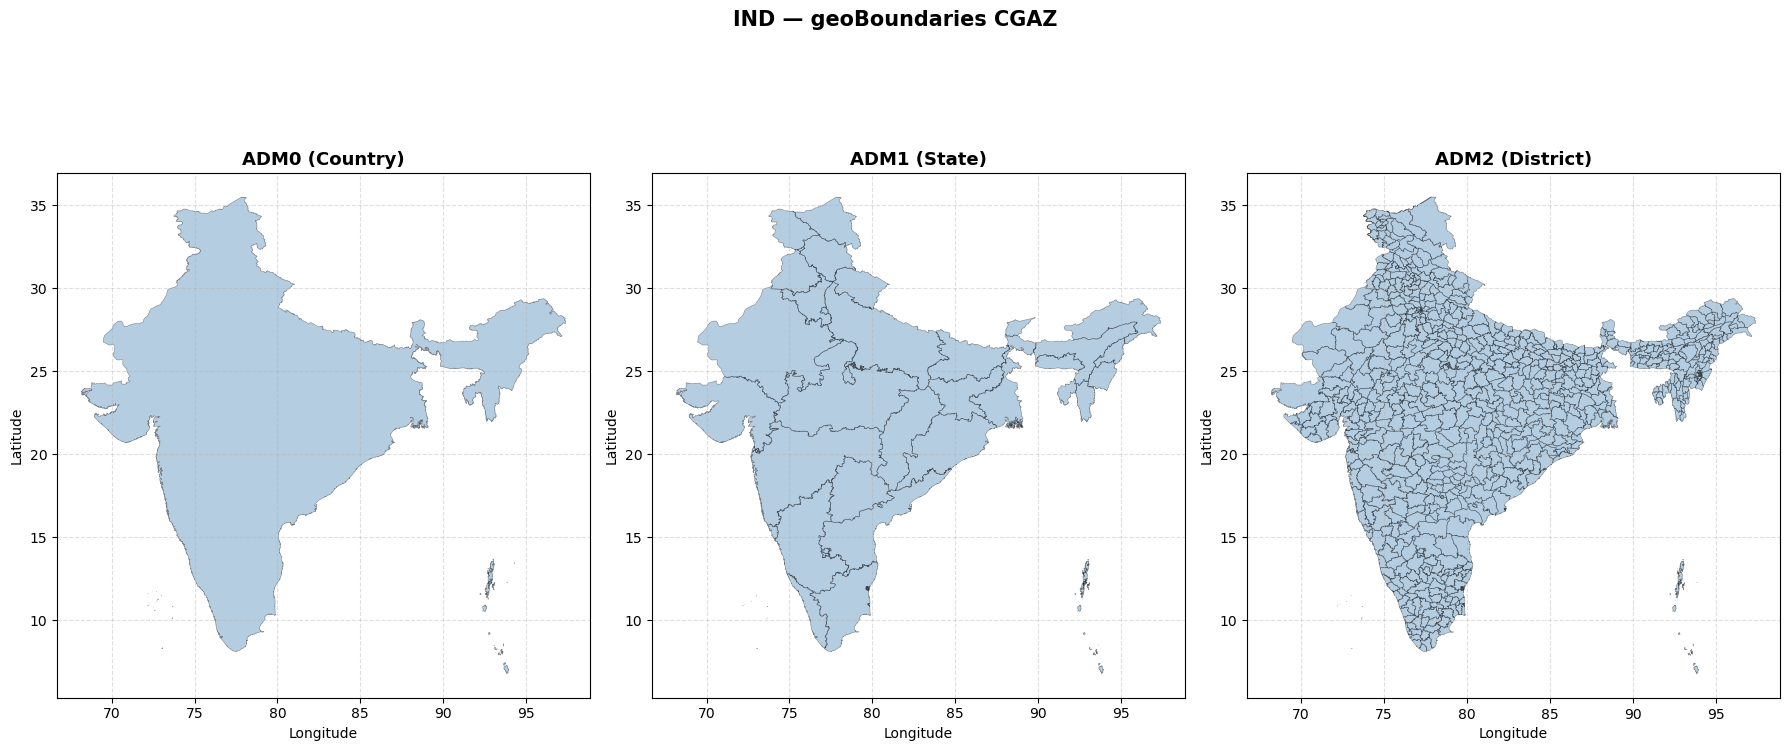

In [95]:
# ── Visualise all three levels together ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (label, gdf) in zip(axes, [
    ('ADM0 (Country)', india_adm0),
    ('ADM1 (State)',   india_adm1),
    ('ADM2 (District)',india_adm2),
]):
    gdf.plot(ax=ax, edgecolor='black', linewidth=0.4,
             facecolor='steelblue', alpha=0.4)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'{COUNTRY} — geoBoundaries CGAZ', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

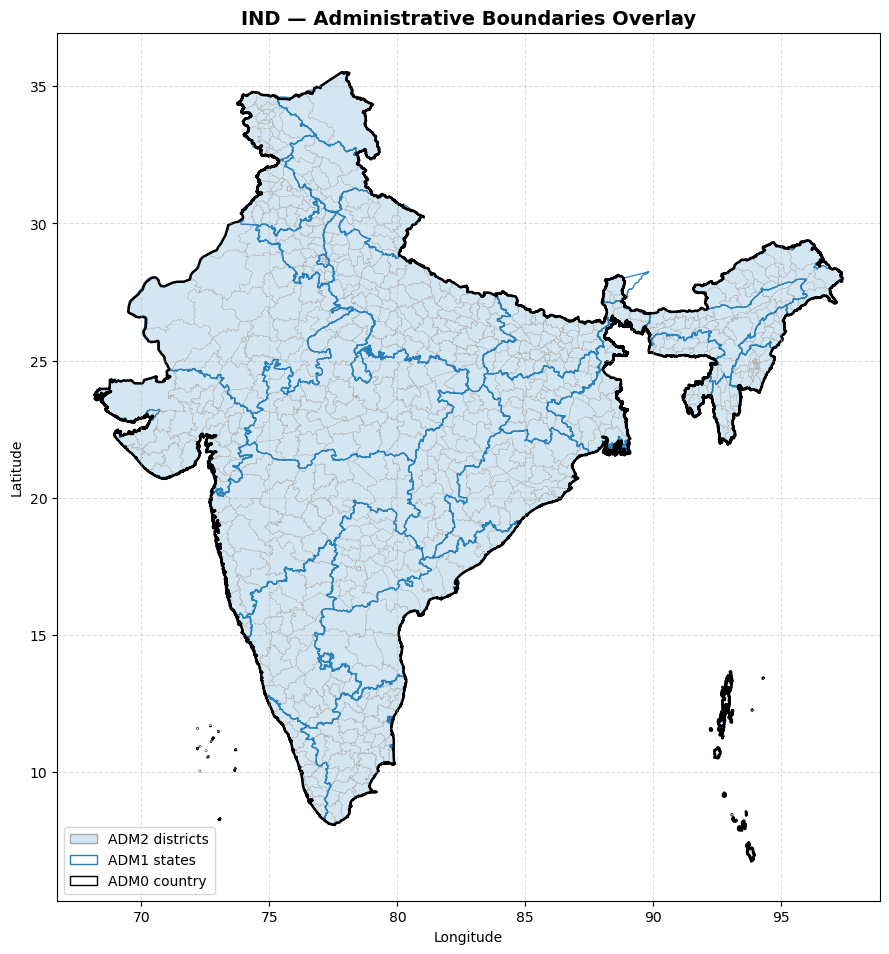

In [96]:
# ── Overlay all levels on one map ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

india_adm2.plot(ax=ax, facecolor='#d4e6f1', edgecolor='#aaa', linewidth=0.3, label='ADM2')
india_adm1.plot(ax=ax, facecolor='none',    edgecolor='#2980b9', linewidth=0.9, label='ADM1')
india_adm0.plot(ax=ax, facecolor='none',    edgecolor='black',   linewidth=1.8, label='ADM0')

patches = [
    mpatches.Patch(facecolor='#d4e6f1', edgecolor='#aaa',    label='ADM2 districts'),
    mpatches.Patch(facecolor='none',    edgecolor='#2980b9', label='ADM1 states'),
    mpatches.Patch(facecolor='none',    edgecolor='black',   label='ADM0 country'),
]
ax.legend(handles=patches, loc='lower left', fontsize=10)
ax.set_title(f'{COUNTRY} — Administrative Boundaries Overlay', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [97]:
overview_img = Image.open(overview_png_path)
overview_img.show()

In [98]:
centroid_image = Image.open(centroid_detail_png_path)
centroid_image.show()

#### Data

In [99]:
testing_filepaths(step0_raw_data_2018_01_path)
testing_filepaths(step0_raw_data_2018_03_path)
testing_filepaths(step1_masked_data_2018_01_path)
testing_filepaths(step1_masked_data_2018_03_path)
testing_filepaths(step2_trimmed_data_2018_01_path)
testing_filepaths(step2_trimmed_data_2018_03_path)
testing_filepaths(step3_consolidated_data_2018_path)
testing_filepaths(step4_interpolated_data_2018_path)
testing_filepaths(step5_interpolated_boundary_fixed_data_2018_path)
testing_filepaths(step6_interpolated_final_data_2018_path)
testing_filepaths(step7_processed_data_2018_path)

Testing filepath for [era5-world_N37W68S6E98_d514a3a3c256_2018-01.grib]:
  - MIME type: application/grib;edition=1
  - Magic bytes: b'GRIB\x00v\x96\x01'
Testing filepath for [era5-world_N37W68S6E98_d514a3a3c256_2018-03.grib]:
  - MIME type: application/grib;edition=1
  - Magic bytes: b'GRIB\x00v\x96\x01'
Testing filepath for [era5-world_INDIA_916d3fbb_2018_01.parquet]:
  - MIME type: application/octet-stream
  - Magic bytes: b'PAR1\x15\x00\x15\xd0'
Testing filepath for [era5-world_INDIA_916d3fbb_2018_03.parquet]:
  - MIME type: application/octet-stream
  - Magic bytes: b'PAR1\x15\x00\x15\xd0'
Testing filepath for [era5-world_INDIA_916d3fbb_2018_01.parquet]:
  - MIME type: application/octet-stream
  - Magic bytes: b'PAR1\x15\x04\x15\x0e'
Testing filepath for [era5-world_INDIA_916d3fbb_2018_03.parquet]:
  - MIME type: application/octet-stream
  - Magic bytes: b'PAR1\x15\x04\x15\x0e'
Testing filepath for [era5-world_INDIA_916d3fbb_2018.parquet]:
  - MIME type: application/octet-stream
  -

In [100]:
step1_masked_data_2018_01_pldf = pl.read_parquet(source=step1_masked_data_2018_01_path)
step1_masked_data_2018_03_pldf = pl.read_parquet(source=step1_masked_data_2018_03_path)
step2_trimmed_data_2018_01_pldf = pl.read_parquet(source=step2_trimmed_data_2018_01_path)
step2_trimmed_data_2018_03_pldf = pl.read_parquet(source=step2_trimmed_data_2018_03_path)
step3_consolidated_data_2018_pldf = pl.read_parquet(source=step3_consolidated_data_2018_path)
step4_interpolated_data_2018_pldf = pl.read_parquet(source=step4_interpolated_data_2018_path)
step5_interpolated_boundary_fixed_data_2018_pldf = pl.read_parquet(source=step5_interpolated_boundary_fixed_data_2018_path)
step6_interpolated_final_data_2018_pldf = pl.read_parquet(source=step6_interpolated_final_data_2018_path)
step7_processed_data_2018_pldf = pl.read_parquet(source=step7_processed_data_2018_path)

##### Step 1 Data

In [106]:
# Describe
print('Step 1 Masked Data 2018-01 Description')
display(step1_masked_data_2018_01_pldf.describe())
print('Step 1 Masked Data 2018-03 Description')
display(step1_masked_data_2018_03_pldf.describe())

Step 1 Masked Data 2018-01 Description


statistic,latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",3.358152e6,3.358152e6,"""3358152""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.358152e6,"""3358152""","""3358152""","""3358152""","""3358152""","""3358152""","""3358152"""
"""null_count""",0.0,0.0,"""0""",53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",22.886875,79.613519,"""2018-01-16 12:30:00""",-0.351464,-0.888849,-0.178635,-0.516106,289.690674,609923.3125,0.279998,0.663284,564936.75,0.066978,-16.497999,1.776128,1.627019,0.065957,0.061619,582850.125,608595.0,717708.25,748963.75,-314977.625,-333587.4375,1.120844e6,1.1010e6,0.162325,0.000009,814553.8125,839555.875,-1.0134e6,-1.0220e6,77395.328125,1.0,null,null,null,null,null,null
"""std""",5.504277,5.880584,null,2.772204,2.121214,1.632763,1.256959,10.166892,861944.375,0.31615,0.325827,822113.75,0.203259,19.83663,1.241123,0.715686,0.192645,0.167814,825875.6875,852993.6875,997127.375,1.0279e6,128049.90625,113481.773438,172052.5,174847.734375,0.285761,0.000085,1.1119e6,1.1408e6,105084.382812,96098.226562,109323.125,0.0,null,null,null,null,null,null
"""min""",8.25,68.25,"""2017-12-31 19:00:00""",-10.011185,-10.840759,-7.533813,-8.027176,229.620056,0.0,0.0,0.0,0.0,0.0,-89.317909,0.0,0.0,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-870358.0,-864090.5,323103.375,332315.6875,0.0,0.0,0.0,0.0,-1.273476e6,-1.265231e6,0.0,1.0,"""India""","""IND""","""Andhra Pradesh""","""1811400B11231190780494""","""Adilabad""","""76128533B10727492375508"""
"""25%""",19.5,75.5,"""2018-01-08 16:00:00""",-2.201477,-2.239334,-1.377945,-1.398041,285.546509,0.0,0.00238,0.416563,0.0,0.0,-29.786163,0.980957,1.153442,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-400384.375,-411577.0625,1.0471e6,1.0381e6,0.0,0.0,0.0,0.0,-1.072172e6,-1.076325e6,0.0,1.0,null,null,null,null,null,null
"""50%""",23.5,78.25,"""2018-01-16 13:00:00""",-0.395096,-0.855118,-0.268677,-0.556458,290.952026,0.0,0.149811,0.755631,0.0,0.0,-19.621788,1.920044,1.560791,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-277176.0,-288893.0,1127272.5,1.1160e6,0.0,0.0,0.0,0.0,-1.029763e6,-1.034184e6,0.0,1.0,null,null,null,null,null,null
"""75%""",26.75,82.5,"""2018-01-24 09:00:00""",1.364853,0.468353,0.941086,0.340149,296.254761,1.297024e6,0.504298,0.976124,1.13344e6,0.0,-4.634796,2.310913,2.165894,0.004578,0.012146,1.191552e6,1.279552e6,1.525888e6,1.630272e6,-232995.375,-249491.0,1.2204e6,1.2023e6,0.194061,0.0,1.729408e6,1.803136e6,-983334.0,-989749.0,159952.0,1.0,null,null,null,null,null,null
"""max""",35.25,97.25,"""2018-02-01 06:00:00""",11.976593,9.605347,8.431534,5.483978,309.279175,3.029888e6,1.0,1.0,3.05984e6,1.0,38.759247,6.252563,3.683105,1.0,1.0,3.058816e6,3.15776e6,3.475264e6,3.45952e6,103486.1875,-93737.1875,1.6290e6,1.576104e6,1.0,0.009217,4.01024e6,4.108288e6,-451954.0,-507424.0,408032.0,1.0,"""India""","""IND""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""","""NONE_DEFINED"""


Step 1 Masked Data 2018-03 Description


statistic,latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",3.358152e6,3.358152e6,"""3358152""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.358152e6,"""3358152""","""3358152""","""3358152""","""3358152""","""3358152""","""3358152"""
"""null_count""",0.0,0.0,"""0""",53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,53304.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",22.886875,79.613519,"""2018-03-16 12:30:00""",0.505887,-0.333618,0.322759,-0.161102,297.637695,829446.9375,0.279998,0.663284,722734.1875,0.136995,13.828256,1.713849,1.5804,0.045455,0.120052,748057.0625,811981.1875,935403.875,1.0132e6,-343439.03125,-368020.09375,1.261911e6,1.2354e6,0.242144,0.000034,1073794.5,1.1374e6,-1.013309e6,-1.0470e6,105457.304688,1.0,null,null,null,null,null,null
"""std""",5.504277,5.880584,null,3.154688,2.696287,1.91698,1.586312,10.346111,1.088636e6,0.31615,0.325827,998566.1875,0.271542,16.186184,1.193714,0.706669,0.160582,0.218157,994359.5,1.0566e6,1.2182e6,1.2894e6,157640.03125,142857.234375,180002.875,185670.71875,0.320921,0.000241,1.3601e6,1.4266e6,127743.59375,96374.09375,139469.9375,0.0,null,null,null,null,null,null
"""min""",8.25,68.25,"""2018-02-28 19:00:00""",-11.633621,-11.934555,-9.442978,-8.083618,234.584061,0.0,0.0,0.0,0.0,0.0,-117.629463,0.0,0.0,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-1.093134e6,-1.09246e6,352711.625,336971.0,0.0,0.0,0.0,0.0,-1.409894e6,-1.414566e6,0.0,1.0,"""India""","""IND""","""Andhra Pradesh""","""1811400B11231190780494""","""Adilabad""","""76128533B10727492375508"""
"""25%""",19.5,75.5,"""2018-03-08 16:00:00""",-1.506302,-2.123947,-0.970047,-1.300034,294.84906,0.0,0.00238,0.416563,0.0,0.0,4.775963,0.969238,1.089111,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-438697.0,-456178.0,1.2000e6,1.1900e6,0.0,0.0,0.0,0.0,-1.085565e6,-1.098862e6,0.0,1.0,null,null,null,null,null,null
"""50%""",23.5,78.25,"""2018-03-16 13:00:00""",0.417374,-0.398102,0.255768,-0.239258,298.846436,12480.0,0.149811,0.755631,7680.0,0.0,18.334229,1.837646,1.508789,0.0,0.001678,27904.0,29376.0,36992.0,40640.0,-299610.0,-316953.0,1.28216e6,1.265323e6,0.062592,0.0,72192.0,74240.0,-1.036711e6,-1.051778e6,4552.0,1.0,null,null,null,null,null,null
"""75%""",26.75,82.5,"""2018-03-24 09:00:00""",2.642899,1.370575,1.662552,0.921417,304.041504,1.788032e6,0.504298,0.976124,1.472384e6,0.10437,26.160278,2.280151,2.10376,0.0,0.150116,1.55168e6,1.721664e6,1.978432e6,2.202432e6,-237293.75,-262579.0,1.3657e6,1.3391e6,0.40686,0.0,2.270464e6,2.437248e6,-978025.0,-1.01535e6,219016.0,1.0,null,null,null,null,null,null
"""max""",35.25,97.25,"""2018-04-01 06:00:00""",12.165634,11.198059,9.615158,8.422836,317.553223,3.49632e6,1.0,1.0,3.457344e6,1.0,43.424789,6.187012,3.606445,1.0,1.0,3.404672e6,3.478208e6,3.985664e6,3.975488e6,72868.0,-119274.5625,1.7099e6,1651395.5,1.0,0.017243,4.456192e6,4.452736e6,-317591.0,-539888.0,488184.0,1.0,"""India""","""IND""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""","""NONE_DEFINED"""


In [107]:
print('Step 1 Masked Data 2018-01 — First 8 rows:')
display(step1_masked_data_2018_01_pldf.head(8))
print('Step 1 Masked Data 2018-01 — Last 8 rows:')
display(step1_masked_data_2018_01_pldf.tail(8))

Step 1 Masked Data 2018-01 — First 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2017-12-31 19:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 20:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 21:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 22:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 23:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 00:00:00,1.377716,-0.158432,0.284775,-0.811127,240.809692,0.0,0.0,0.005654,0.0,0.0,-20.509537,0.0,0.284668,0.581116,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,0.64978,0.000001,0.0,0.0,-538943.0,-534469.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 01:00:00,1.382904,-0.270203,0.245407,-0.813004,241.025314,0.0,0.0,0.005654,0.0,0.0,-20.390999,0.0,0.284668,0.758057,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,0.837372,0.000002,0.0,0.0,-535883.0,-531899.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 02:00:00,1.268295,0.019287,0.249374,-0.791077,240.921371,0.0,0.0,0.005654,0.0,0.0,-20.531189,0.0,0.284668,0.468719,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,0.653595,0.000001,0.0,0.0,-533275.0,-530085.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


Step 1 Masked Data 2018-01 — Last 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
8.25,77.75,2018-01-31 23:00:00,-4.359802,-7.455994,-3.253738,-5.659195,297.857361,0.0,0.031433,0.958844,0.0,0.505951,24.949844,1.013184,0.768677,0.0,0.002869,3.6000e-12,0.0,0.0,0.0,-243240.0,-277451.5,1363437.5,1.3447e6,0.507385,0.0,0.0,0.0,-890226.0,-982130.0,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 06:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


In [108]:
print('Step 1 Masked Data 2018-03 — First 8 rows:')
display(step1_masked_data_2018_03_pldf.head(8))
print('Step 1 Masked Data 2018-03 — Last 8 rows:')
display(step1_masked_data_2018_03_pldf.tail(8))

Step 1 Masked Data 2018-03 — First 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2018-02-28 19:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 20:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 21:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 22:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-02-28 23:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 00:00:00,1.270325,1.865829,0.297806,0.010498,251.97168,0.0,0.0,0.005654,0.0,0.008972,-12.020073,0.0,0.284668,0.997223,0.499878,3.6000e-12,0.0,0.0,0.0,-36813.8125,-257582.9375,697415.625,473943.0625,1.0,0.000104,0.0,0.0,-644510.0,-647064.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 01:00:00,1.005737,1.778397,0.252975,-0.068619,251.62442,0.0,0.0,0.005654,0.0,0.0,-11.947891,0.0,0.284668,0.993774,0.994995,3.6000e-12,0.0,0.0,0.0,-66497.5625,-274994.625,662521.5625,472942.375,1.0,0.000091,0.0,0.0,-633183.0,-655041.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-03-01 02:00:00,0.944382,1.793793,0.258514,-0.080811,252.231094,51072.0,0.0,0.005654,14208.0,0.065552,-11.815445,0.0,0.284668,0.993103,1.0,11968.0,16000.0,69248.0,95040.0,-57701.125,-264342.5625,671025.375,471949.0625,1.0,0.000092,68480.0,72704.0,-627804.0,-648954.0,8776.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


Step 1 Masked Data 2018-03 — Last 8 rows:


latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
8.25,77.75,2018-03-31 23:00:00,3.966568,0.761215,3.041595,0.917892,300.087402,0.0,0.031433,0.958844,0.0,0.0,23.485168,1.013184,0.752563,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-255085.6875,-266842.4375,1.3915e6,1.3987e6,0.0,0.0,0.0,0.0,-1.050148e6,-1.052402e6,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-04-01 06:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


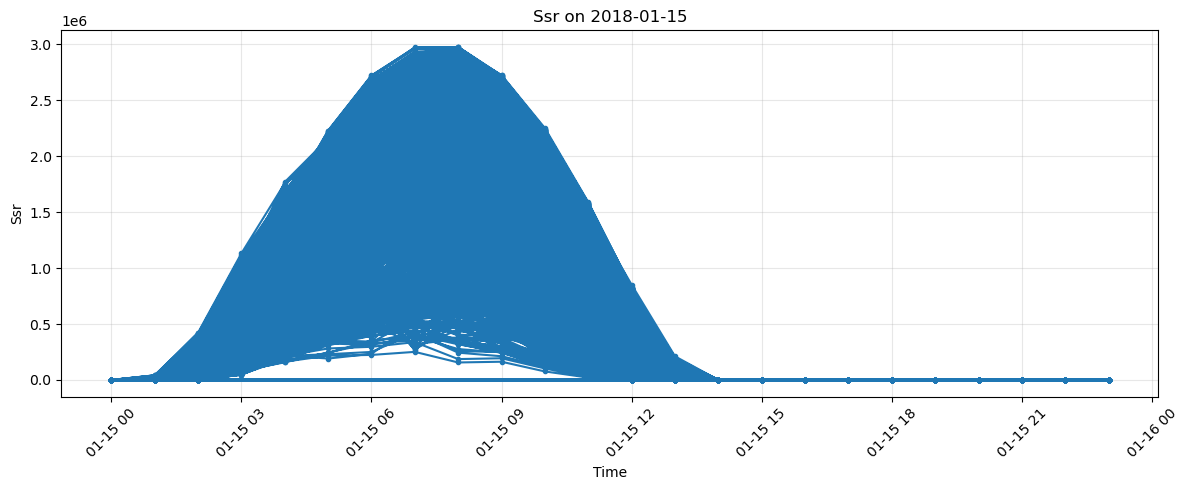

latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm0_name,adm0_code,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str,str,str
35.25,77.5,2018-01-15 00:00:00,1.913864,1.43219,0.61496,-0.352936,241.832947,0.0,0.0,0.005654,0.0,0.0,-36.866035,0.0,0.284668,0.972046,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,0.972046,0.000004,0.0,0.0,-580215.0,-578913.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 01:00:00,1.70842,1.734161,0.591339,-0.286331,241.79158,0.0,0.0,0.005654,0.0,0.0,-35.825348,0.0,0.284668,0.974152,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,0.974152,0.000003,0.0,0.0,-575022.0,-573343.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 02:00:00,1.671066,1.995972,0.626221,-0.147141,241.885132,0.0,0.0,0.005654,0.0,0.0,-34.497498,0.0,0.284668,0.854095,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,0.854095,0.000002,0.0,0.0,-572226.0,-568834.0,0.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 03:00:00,1.683121,2.038452,0.616745,-0.111084,241.973267,195968.0,0.0,0.005654,162112.0,0.0,-33.316917,0.0,0.284668,0.864075,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,0.864777,0.000002,157184.0,160768.0,-572073.0,-567374.0,26768.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-15 04:00:00,1.781586,2.215454,0.581116,-0.021484,241.039505,826816.0,0.0,0.005654,777152.0,0.0,-32.895897,0.0,0.284668,0.837189,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,0.837189,0.000001,429952.0,448896.0,-589513.0,-583209.0,104960.0,1.0,"""India""","""IND""","""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8.25,77.75,2018-01-15 19:00:00,-4.544662,-7.413864,-3.132797,-5.315994,297.973267,0.0,0.031433,0.958844,0.0,0.865875,12.092262,1.013184,0.787109,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-297672.0,-309725.0,1.3030e6,1306814.5,0.865875,0.0,0.0,0.0,-1.05832e6,-1.063787e6,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-01-15 20:00:00,-4.116135,-7.636276,-2.842056,-5.483734,297.305817,0.0,0.031433,0.958844,0.0,0.995697,12.584808,1.013184,0.786987,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-291130.0,-309602.0,1.3064e6,1.307694e6,0.995697,0.0,0.0,0.0,-1.049469e6,-1.061955e6,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-01-15 21:00:00,-3.379288,-7.742966,-2.333893,-5.535385,297.066467,0.0,0.031433,0.958844,0.0,1.0,13.226654,1.013184,0.786987,0.0,0.0,3.6000e-12,0.0,0.0,0.0,-268272.0,-304450.0,1326373.5,1.3100e6,1.0,0.0,0.0,0.0,-1.042689e6,-1.058559e6,0.0,1.0,"""India""","""IND""","""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


In [113]:
plot_day_polars_direct(step1_masked_data_2018_01_pldf, date='2018-01-15', column='ssr')

##### Step 2 Data

In [114]:
# Describe
print('Step 2 Trimmed Data 2018-01 Description')
display(step2_trimmed_data_2018_01_pldf.describe())
print('Step 2 Trimmed Data 2018-03 Description')
display(step2_trimmed_data_2018_03_pldf.describe())

Step 2 Trimmed Data 2018-01 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,"""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,609923.3125,0.279998,0.663284,564936.75,1.0,0.066978,-16.497999,1.776128,1.627019,22.886875,0.065957,79.613518,0.061619,582850.125,608595.0,717708.25,748963.75,-314977.625,-333587.4375,1.120844e6,1.1010e6,289.690674,0.162325,"""2018-01-16 11:29:59.999999""",0.000009,814553.8125,839555.875,-1.0134e6,-1.0220e6,-0.178635,-0.351464,77395.328125,-0.516106,-0.888849
"""std""",null,null,null,null,null,null,861944.375,0.31615,0.325827,822113.75,0.0,0.203259,19.83663,1.241123,0.715686,5.504277,0.192645,5.880584,0.167814,825875.6875,852993.6875,997127.375,1.0279e6,128049.90625,113481.773438,172052.5,174847.734375,10.166892,0.285761,null,0.000085,1.1119e6,1.1408e6,105084.382812,96098.226562,1.632763,2.772204,109323.125,1.256959,2.121214
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-89.317909,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-870358.0,-864090.5,323103.375,332315.6875,229.620056,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-1.273476e6,-1.265231e6,-7.533813,-10.011185,0.0,-8.027176,-10.840759
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,-29.786163,0.980957,1.153442,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-400384.375,-411577.0625,1.0471e6,1.0381e6,285.546509,0.0,"""2018-01-08 18:00:00""",0.0,0.0,0.0,-1.072172e6,-1.076325e6,-1.377945,-2.201477,0.0,-1.398041,-2.239334
"""50%""",null,null,null,null,null,null,0.0,0.149811,0.755631,0.0,1.0,0.0,-19.621788,1.920044,1.560791,23.5,0.0,78.25,0.0,3.6000e-12,0.0,0.0,0.0,-277176.0,-288893.0,1127272.5,1.1160e6,290.952026,0.0,"""2018-01-16 12:00:00""",0.0,0.0,0.0,-1.029763e6,-1.034184e6,-0.268677,-0.395096,0.0,-0.556458,-0.855118
"""75%""",null,null,null,null,null,null,1.297024e6,0.504298,0.976124,1.13344e6,1.0,0.0,-4.634796,2.310913,2.165894,26.75,0.004578,82.5,0.012146,1.191552e6,1.279552e6,1.525888e6,1.630272e6,-232995.375,-249491.0,1.2204e6,1.2023e6,296.254761,0.194061,"""2018-01-24 05:00:00""",0.0,1.729408e6,1.803136e6,-983334.0,-989749.0,0.941086,1.364853,159952.0,0.340149,0.468353
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.029888e6,1.0,1.0,3.05984e6,1.0,1.0,38.759247,6.252563,3.683105,35.25,1.0,97.25,1.0,3.058816e6,3.15776e6,3.475264e6,3.45952e6,103486.1875,-93737.1875,1.6290e6,1.576104e6,309.279175,1.0,"""2018-01-31 23:00:00""",0.009217,4.01024e6,4.108288e6,-451954.0,-507424.0,8.431534,11.976593,408032.0,5.483978,9.605347


Step 2 Trimmed Data 2018-03 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""","""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,"""3304848""",3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6,3.304848e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,829446.9375,0.279998,0.663284,722734.1875,1.0,0.136995,13.828256,1.713849,1.5804,22.886875,0.045455,79.613518,0.120052,748057.0625,811981.1875,935403.875,1.0132e6,-343439.03125,-368020.09375,1.261911e6,1.2354e6,297.637695,0.242144,"""2018-03-16 11:30:00""",0.000034,1073794.5,1.1374e6,-1.013309e6,-1.0470e6,0.322759,0.505887,105457.304688,-0.161102,-0.333618
"""std""",null,null,null,null,null,null,1.088636e6,0.31615,0.325827,998566.1875,0.0,0.271542,16.186184,1.193714,0.706669,5.504277,0.160582,5.880584,0.218157,994359.5,1.0566e6,1.2182e6,1.2894e6,157640.03125,142857.234375,180002.875,185670.71875,10.346111,0.320921,null,0.000241,1.3601e6,1.4266e6,127743.59375,96374.09375,1.91698,3.154688,139469.9375,1.586312,2.696287
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-1.093134e6,-1.09246e6,352711.625,336971.0,234.584061,0.0,"""2018-03-01 00:00:00""",0.0,0.0,0.0,-1.409894e6,-1.414566e6,-9.442978,-11.633621,0.0,-8.083618,-11.934555
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,4.775963,0.969238,1.089111,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-438697.0,-456178.0,1.2000e6,1.1900e6,294.84906,0.0,"""2018-03-08 18:00:00""",0.0,0.0,0.0,-1.085565e6,-1.098862e6,-0.970047,-1.506302,0.0,-1.300034,-2.123947
"""50%""",null,null,null,null,null,null,12480.0,0.149811,0.755631,7680.0,1.0,0.0,18.334229,1.837646,1.508789,23.5,0.0,78.25,0.001678,27904.0,29376.0,36992.0,40640.0,-299610.0,-316953.0,1.28216e6,1.265323e6,298.846436,0.062592,"""2018-03-16 12:00:00""",0.0,72192.0,74240.0,-1.036711e6,-1.051778e6,0.255768,0.417374,4552.0,-0.239258,-0.398102
"""75%""",null,null,null,null,null,null,1.788032e6,0.504298,0.976124,1.472384e6,1.0,0.10437,26.160278,2.280151,2.10376,26.75,0.0,82.5,0.150116,1.55168e6,1.721664e6,1.978432e6,2.202432e6,-237293.75,-262579.0,1.3657e6,1.3391e6,304.041504,0.40686,"""2018-03-24 05:00:00""",0.0,2.270464e6,2.437248e6,-978025.0,-1.01535e6,1.662552,2.642899,219016.0,0.921417,1.370575
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.49632e6,1.0,1.0,3.457344e6,1.0,1.0,43.424789,6.187012,3.606445,35.25,1.0,97.25,1.0,3.404672e6,3.478208e6,3.985664e6,3.975488e6,72868.0,-119274.5625,1.7099e6,1651395.5,317.553223,1.0,"""2018-03-31 23:00:00""",0.017243,4.456192e6,4.452736e6,-317591.0,-539888.0,9.615158,12.165634,488184.0,8.422836,11.198059


In [115]:
print('Step 2 Trimmed Data 2018-01 — First 8 rows:')
display(step2_trimmed_data_2018_01_pldf.head(8))
print('Step 2 Trimmed Data 2018-01 — Last 8 rows:')
display(step2_trimmed_data_2018_01_pldf.tail(8))

Step 2 Trimmed Data 2018-01 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.509537,0.0,0.284668,35.25,0.581116,77.5,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,240.809692,0.64978,2018-01-01 00:00:00,0.000001,0.0,0.0,-538943.0,-534469.0,0.284775,1.377716,0.0,-0.811127,-0.158432
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.390999,0.0,0.284668,35.25,0.758057,77.5,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,241.025314,0.837372,2018-01-01 01:00:00,0.000002,0.0,0.0,-535883.0,-531899.0,0.245407,1.382904,0.0,-0.813004,-0.270203
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.531189,0.0,0.284668,35.25,0.468719,77.5,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,240.921371,0.653595,2018-01-01 02:00:00,0.000001,0.0,0.0,-533275.0,-530085.0,0.249374,1.268295,0.0,-0.791077,0.019287
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",181184.0,0.0,0.005654,177152.0,1.0,0.0,-21.180832,0.0,0.284668,35.25,0.580414,77.5,0.241852,47872.0,46144.0,258752.0,261184.0,-138297.0,-135713.0,379923.9375,371232.875,239.965469,0.597504,2018-01-01 03:00:00,9.5367e-7,146944.0,144640.0,-535470.0,-528148.0,0.247238,1.172256,25776.0,-0.786148,0.400345
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",783104.0,0.0,0.005654,716288.0,1.0,0.0,-21.873825,0.0,0.284668,35.25,0.609406,77.5,0.168884,170176.0,176256.0,952384.0,977856.0,-162683.0,-159374.0,386818.3125,370614.0625,237.582184,0.628021,2018-01-01 04:00:00,9.5367e-7,388864.0,392832.0,-553803.0,-540888.0,0.280487,1.242538,98704.0,-0.803772,0.582336
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.376256e6,0.0,0.005654,1.327552e6,1.0,0.0,-22.199249,0.0,0.284668,35.25,0.643738,77.5,0.202515,284288.0,289984.0,1.609984e6,1.628352e6,-192507.0,-194113.0,392493.5,371087.6875,240.023376,0.658051,2018-01-01 05:00:00,9.5367e-7,582784.0,582528.0,-572742.0,-560237.0,0.331802,1.392273,179832.0,-0.726242,0.680954
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.80192e6,0.0,0.005654,1.77952e6,1.0,0.0,-22.378044,0.0,0.284668,35.25,0.738007,77.5,0.199219,365568.0,370432.0,2.081408e6,2.089472e6,-228657.0,-227705.0,383090.75,371890.375,239.979141,0.748688,2018-01-01 06:00:00,9.5367e-7,711168.0,712832.0,-585433.0,-578824.0,0.376938,1.601379,237248.0,-0.59053,0.860504
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.004928e6,0.0,0.005654,1.983744e6,1.0,0.0,-20.380753,0.0,0.284668,35.25,0.731049,77.5,0.175751,404800.0,409280.0,2.30848e6,2.311616e6,-247917.9375,-247993.0,381401.6875,375739.5,240.514847,0.731049,2018-01-01 07:00:00,0.000003,776192.0,779776.0,-595411.0,-592267.0,0.407196,1.574203,267704.0,-0.530182,0.839294


Step 2 Trimmed Data 2018-01 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.952087,26.455223,1.013184,0.769043,8.25,0.0,77.75,0.005768,3.6000e-12,0.0,0.0,0.0,-225680.125,-236022.0,1.405376e6,1402256.5,299.746826,0.952087,2018-01-31 16:00:00,0.0,0.0,0.0,-916909.0,-985109.0,-3.996643,-5.261063,0.0,-4.559784,-6.034821
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.881561,26.458466,1.013184,0.768921,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-220780.0,-233535.0,1403821.5,1400808.5,299.206573,0.881561,2018-01-31 17:00:00,0.0,0.0,0.0,-950770.0,-982509.0,-3.967194,-5.296204,0.0,-4.862717,-6.479614
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.839111,25.56282,1.013184,0.768921,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-214624.0,-235053.0,1405818.5,1.3970e6,299.371521,0.839111,2018-01-31 18:00:00,0.0,0.0,0.0,-927215.0,-980962.0,-3.596283,-4.858612,0.0,-5.401962,-7.245346
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.95929,24.646439,1.013184,0.768799,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-220750.0,-243887.0,1.4028e6,1.385821e6,299.245239,0.95929,2018-01-31 19:00:00,0.0,0.0,0.0,-806730.0,-982491.0,-2.888184,-3.907913,0.0,-5.571381,-7.537567
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.90863,24.924934,1.013184,0.768799,8.25,0.0,77.75,0.002869,3.6000e-12,0.0,0.0,0.0,-234465.375,-255580.0,1385615.5,1.3768e6,298.742859,0.910065,2018-01-31 20:00:00,0.0,0.0,0.0,-870954.0,-982798.0,-2.890503,-3.82637,0.0,-5.492416,-7.450134
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.736328,23.94458,1.013184,0.768799,8.25,0.0,77.75,0.014191,3.6000e-12,0.0,0.0,0.0,-237314.5625,-262400.125,1377574.5,1365373.5,298.438293,0.744751,2018-01-31 21:00:00,0.0,0.0,0.0,-865185.0,-980812.0,-3.129944,-4.188705,0.0,-5.552292,-7.473129
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.826233,24.150993,1.013184,0.768677,8.25,0.0,77.75,0.013977,3.6000e-12,0.0,0.0,0.0,-233093.6875,-270168.6875,1.3777e6,1.354307e6,298.12326,0.826233,2018-01-31 22:00:00,0.0,0.0,0.0,-878244.0,-981324.0,-3.362762,-4.49469,0.0,-5.355682,-7.049881
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.505951,24.949844,1.013184,0.768677,8.25,0.0,77.75,0.002869,3.6000e-12,0.0,0.0,0.0,-243240.0,-277451.5,1363437.5,1.3447e6,297.857361,0.507385,2018-01-31 23:00:00,0.0,0.0,0.0,-890226.0,-982130.0,-3.253738,-4.359802,0.0,-5.659195,-7.455994


In [116]:
print('Step 2 Trimmed Data 2018-03 — First 8 rows:')
display(step2_trimmed_data_2018_03_pldf.head(8))
print('Step 2 Trimmed Data 2018-03 — Last 8 rows:')
display(step2_trimmed_data_2018_03_pldf.tail(8))

Step 2 Trimmed Data 2018-03 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.008972,-12.020073,0.0,0.284668,35.25,0.997223,77.5,0.499878,3.6000e-12,0.0,0.0,0.0,-36813.8125,-257582.9375,697415.625,473943.0625,251.97168,1.0,2018-03-01 00:00:00,0.000104,0.0,0.0,-644510.0,-647064.0,0.297806,1.270325,0.0,0.010498,1.865829
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-11.947891,0.0,0.284668,35.25,0.993774,77.5,0.994995,3.6000e-12,0.0,0.0,0.0,-66497.5625,-274994.625,662521.5625,472942.375,251.62442,1.0,2018-03-01 01:00:00,0.000091,0.0,0.0,-633183.0,-655041.0,0.252975,1.005737,0.0,-0.068619,1.778397
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",51072.0,0.0,0.005654,14208.0,1.0,0.065552,-11.815445,0.0,0.284668,35.25,0.993103,77.5,1.0,11968.0,16000.0,69248.0,95040.0,-57701.125,-264342.5625,671025.375,471949.0625,252.231094,1.0,2018-03-01 02:00:00,0.000092,68480.0,72704.0,-627804.0,-648954.0,0.258514,0.944382,8776.0,-0.080811,1.793793
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",581056.0,0.0,0.005654,264768.0,1.0,0.08078,-11.861122,0.0,0.284668,35.25,0.991028,77.5,1.0,104960.0,137856.0,613824.0,790592.0,-109138.6875,-276085.0625,632763.9375,472455.75,249.598297,1.0,2018-03-01 03:00:00,0.000093,374144.0,389888.0,-623647.0,-654137.0,0.295685,1.103256,77000.0,-0.144943,1.76387
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.331904e6,0.0,0.005654,619008.0,1.0,0.265015,-12.107979,0.0,0.284668,35.25,0.987549,77.5,0.68631,215040.0,281408.0,1.27744e6,1.641344e6,-117869.0625,-296970.4375,665898.25,475620.0,249.992188,0.999298,2018-03-01 04:00:00,0.000082,662144.0,673408.0,-625343.0,-665696.0,0.293777,1.071777,164168.0,0.021942,1.880524
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.994624e6,0.0,0.005654,1.174144e6,1.0,0.559662,-12.382011,0.0,0.284668,35.25,0.992401,77.5,0.629211,319808.0,403136.0,1.901248e6,2.373056e6,-179471.0,-335045.0,634822.3125,480837.4375,254.047775,0.999298,2018-03-01 05:00:00,0.000068,912384.0,901888.0,-653247.0,-687297.0,0.336197,0.987701,253312.0,0.146881,1.944427
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.480064e6,0.0,0.005654,1.600128e6,1.0,0.029999,-12.260254,0.0,0.284668,35.25,0.992401,77.5,0.919281,417856.0,491200.0,2.5072e6,2.903872e6,-225742.0,-352860.0,615257.25,485124.75,254.378189,0.999298,2018-03-01 06:00:00,0.000063,1.09312e6,1.063936e6,-641947.0,-698869.0,0.289185,0.921722,331792.0,0.334824,1.906845
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.731072e6,0.0,0.005654,1.904832e6,1.0,0.0,-10.992744,0.0,0.284668,35.25,0.991699,77.5,0.654907,502912.0,536832.0,2.98272e6,3.182528e6,-257006.25,-391578.1875,622508.0,495649.375,255.044144,1.0,2018-03-01 07:00:00,0.00007,1.209216e6,1.15392e6,-669484.0,-721969.0,0.223022,0.743546,378336.0,0.558609,1.914749


Step 2 Trimmed Data 2018-03 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.004303,26.783234,1.013184,0.752563,8.25,0.0,77.75,0.01413,3.6000e-12,0.0,0.0,0.0,-216802.375,-216808.125,1.4793e6,1.4699e6,303.12735,0.018433,2018-03-31 16:00:00,0.0,0.0,0.0,-1.023679e6,-1.039351e6,3.20816,4.735947,0.0,2.274216,2.53363
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.731018,1.013184,0.752563,8.25,0.0,77.75,0.029663,3.6000e-12,0.0,0.0,0.0,-216510.0,-214441.0,1472127.5,1.4685e6,302.55188,0.029663,2018-03-31 17:00:00,0.0,0.0,0.0,-1.032198e6,-1.03826e6,2.996185,4.444992,0.0,2.162338,2.365768
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.663734,1.013184,0.752563,8.25,0.0,77.75,0.008575,3.6000e-12,0.0,0.0,0.0,-219011.0,-217089.0,1461288.5,1461353.5,302.279053,0.008575,2018-03-31 18:00:00,0.0,0.0,0.0,-1.038207e6,-1.039799e6,2.934692,4.33754,0.0,2.190384,2.485764
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.260231,1.013184,0.752563,8.25,0.0,77.75,0.00412,3.6000e-12,0.0,0.0,0.0,-245275.0,-247007.0,1.4332e6,1.4276e6,301.813812,0.00412,2018-03-31 19:00:00,0.0,0.0,0.0,-1.04684e6,-1.05097e6,2.966461,4.290833,0.0,2.082916,2.436539
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.549934,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255157.0,-258739.0,1.416194e6,1.418241e6,301.296387,0.0,2018-03-31 20:00:00,0.0,0.0,0.0,-1.053651e6,-1.053617e6,2.961044,4.195328,0.0,1.853287,2.184921
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,21.559776,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-254918.0,-262115.0,1.4075e6,1.4100e6,301.004059,0.0,2018-03-31 21:00:00,0.0,0.0,0.0,-1.052344e6,-1.053818e6,2.92337,4.069794,0.0,1.485596,1.735535
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,22.558411,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-253630.0,-264363.0,1.40075e6,1.404222e6,300.500305,0.0,2018-03-31 22:00:00,0.0,0.0,0.0,-1.050258e6,-1.052805e6,3.108322,4.285599,0.0,0.973419,0.889297
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,23.485168,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255085.6875,-266842.4375,1.3915e6,1.3987e6,300.087402,0.0,2018-03-31 23:00:00,0.0,0.0,0.0,-1.050148e6,-1.052402e6,3.041595,3.966568,0.0,0.917892,0.761215


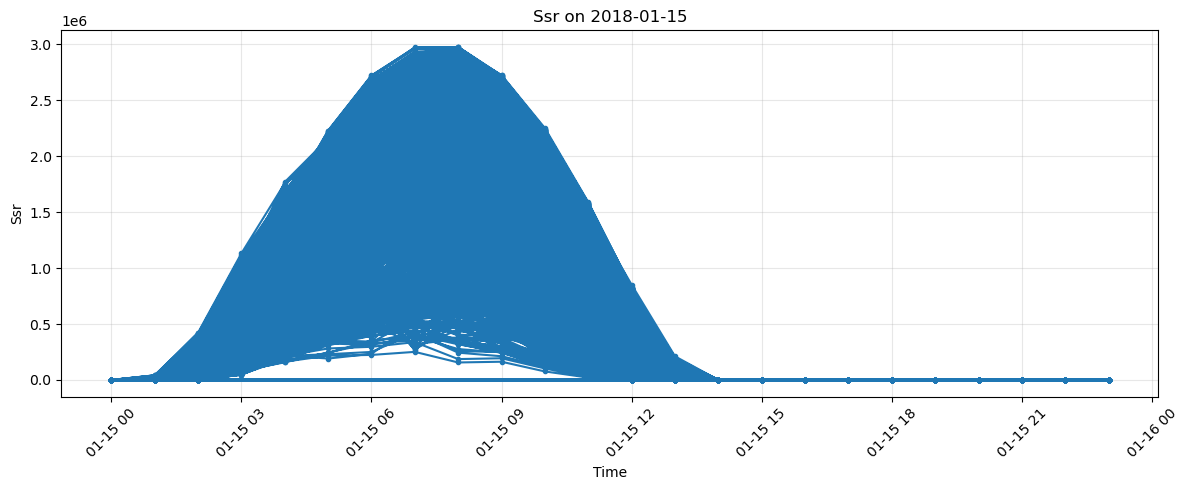

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-36.866035,0.0,0.284668,35.25,0.972046,77.5,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,241.832947,0.972046,2018-01-15 00:00:00,0.000004,0.0,0.0,-580215.0,-578913.0,0.61496,1.913864,0.0,-0.352936,1.43219
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-35.825348,0.0,0.284668,35.25,0.974152,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,241.79158,0.974152,2018-01-15 01:00:00,0.000003,0.0,0.0,-575022.0,-573343.0,0.591339,1.70842,0.0,-0.286331,1.734161
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-34.497498,0.0,0.284668,35.25,0.854095,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,241.885132,0.854095,2018-01-15 02:00:00,0.000002,0.0,0.0,-572226.0,-568834.0,0.626221,1.671066,0.0,-0.147141,1.995972
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",195968.0,0.0,0.005654,162112.0,1.0,0.0,-33.316917,0.0,0.284668,35.25,0.864075,77.5,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,241.973267,0.864777,2018-01-15 03:00:00,0.000002,157184.0,160768.0,-572073.0,-567374.0,0.616745,1.683121,26768.0,-0.111084,2.038452
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",826816.0,0.0,0.005654,777152.0,1.0,0.0,-32.895897,0.0,0.284668,35.25,0.837189,77.5,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,241.039505,0.837189,2018-01-15 04:00:00,0.000001,429952.0,448896.0,-589513.0,-583209.0,0.581116,1.781586,104960.0,-0.021484,2.215454
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.865875,12.092262,1.013184,0.787109,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-297672.0,-309725.0,1.3030e6,1306814.5,297.973267,0.865875,2018-01-15 19:00:00,0.0,0.0,0.0,-1.05832e6,-1.063787e6,-3.132797,-4.544662,0.0,-5.315994,-7.413864
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.995697,12.584808,1.013184,0.786987,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-291130.0,-309602.0,1.3064e6,1.307694e6,297.305817,0.995697,2018-01-15 20:00:00,0.0,0.0,0.0,-1.049469e6,-1.061955e6,-2.842056,-4.116135,0.0,-5.483734,-7.636276
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,13.226654,1.013184,0.786987,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-268272.0,-304450.0,1326373.5,1.3100e6,297.066467,1.0,2018-01-15 21:00:00,0.0,0.0,0.0,-1.042689e6,-1.058559e6,-2.333893,-3.379288,0.0,-5.535385,-7.742966


In [117]:
plot_day_polars_direct(step2_trimmed_data_2018_01_pldf, date='2018-01-15', column='ssr')

##### Step 3 Data

In [118]:
# Describe
print('Step 3 Consolidated Data 2018 Description')
display(step3_consolidated_data_2018_pldf.describe())

Step 3 Consolidated Data 2018 Description


statistic,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""9594720""","""9594720""","""9594720""","""9594720""","""9594720""","""9594720""",9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,"""9594720""",9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6,9.59472e6
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,714282.1875,0.279998,0.663284,631119.25,1.0,0.152504,1.009893,1.74495,1.616583,22.886875,0.056572,79.613518,0.094661,659330.75,706153.25,818783.5,875961.375,-324310.375,-348000.0,1.1927e6,1.167257e6,293.537506,0.245899,"""2018-02-14 23:30:00""",0.000023,938788.9375,984976.9375,-994589.4375,-1.0248e6,0.000833,-0.041326,90661.476562,-0.33509,-0.588525
"""std""",null,null,null,null,null,null,980143.875,0.31615,0.325827,906821.125,0.0,0.301783,22.347317,1.218893,0.71016,5.504277,0.179576,5.880583,0.20497,911941.0,960356.3125,1.109722e6,1165871.5,143130.546875,127723.476562,182434.046875,187770.703125,10.748679,0.341659,null,0.000183,1.2433e6,1.2949e6,128547.117188,96672.164062,1.787991,2.987421,125025.429688,1.441044,2.454588
"""min""","""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",0.0,0.0,0.0,0.0,1.0,0.0,-117.629463,0.0,0.0,8.25,0.0,68.25,0.0,3.6000e-12,0.0,0.0,0.0,-1.093134e6,-1.09246e6,323103.375,319044.125,229.620056,0.0,"""2018-01-01 00:00:00""",0.0,0.0,0.0,-1.409894e6,-1.414566e6,-9.442978,-12.397232,0.0,-8.479828,-12.099319
"""25%""",null,null,null,null,null,null,0.0,0.00238,0.416563,0.0,1.0,0.0,-17.000931,0.971924,1.130371,19.5,0.0,75.5,0.0,3.6000e-12,0.0,0.0,0.0,-412779.8125,-427469.0,1.1126e6,1.0987e6,289.450958,0.0,"""2018-01-23 12:00:00""",0.0,0.0,0.0,-1.070097e6,-1.078991e6,-1.243332,-1.984467,0.0,-1.353058,-2.176697
"""50%""",null,null,null,null,null,null,128.0,0.149811,0.755631,64.0,1.0,0.0,4.433815,1.880859,1.571533,23.5,0.0,78.25,0.0,1920.0,2112.0,2560.0,2752.0,-283640.0,-300738.0,1.2116e6,1.1956e6,295.141418,0.030518,"""2018-02-15 00:00:00""",0.0,5504.0,5888.0,-1.022162e6,-1.034742e6,-0.086639,-0.118698,336.0,-0.407547,-0.624084
"""75%""",null,null,null,null,null,null,1.5216e6,0.504298,0.976124,1.249408e6,1.0,0.092804,20.58268,2.294556,2.14563,26.75,0.0,82.5,0.072479,1.340032e6,1.485504e6,1.711872e6,1.89184e6,-230709.0,-253564.0,1.3060e6,1.282923e6,300.201294,0.428009,"""2018-03-09 11:00:00""",0.0,1.959808e6,2.100352e6,-959775.0,-987887.0,1.228165,1.867523,184664.0,0.625305,0.931564
"""max""","""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",3.49632e6,1.0,1.0,3.457344e6,1.0,1.0,43.424789,6.289917,3.686157,35.25,1.0,97.25,1.0,3.404672e6,3.478208e6,3.985664e6,3.975488e6,116721.0,-93737.1875,1.7099e6,1651395.5,317.553223,1.0,"""2018-03-31 23:00:00""",0.021321,4.456192e6,4.452736e6,-317591.0,-507424.0,9.615158,12.165634,488184.0,8.422836,11.412628


In [119]:
print('Step 3 Consolidated Data 2018 — First 8 rows:')
display(step3_consolidated_data_2018_pldf.head(8))
print('Step 3 Consolidated Data 2018 — Last 8 rows:')
display(step3_consolidated_data_2018_pldf.tail(8))

Step 3 Consolidated Data 2018 — First 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.509537,0.0,0.284668,35.25,0.581116,77.5,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,240.809692,0.64978,2018-01-01 00:00:00,0.000001,0.0,0.0,-538943.0,-534469.0,0.284775,1.377716,0.0,-0.811127,-0.158432
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.390999,0.0,0.284668,35.25,0.758057,77.5,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,241.025314,0.837372,2018-01-01 01:00:00,0.000002,0.0,0.0,-535883.0,-531899.0,0.245407,1.382904,0.0,-0.813004,-0.270203
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-20.531189,0.0,0.284668,35.25,0.468719,77.5,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,240.921371,0.653595,2018-01-01 02:00:00,0.000001,0.0,0.0,-533275.0,-530085.0,0.249374,1.268295,0.0,-0.791077,0.019287
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",181184.0,0.0,0.005654,177152.0,1.0,0.0,-21.180832,0.0,0.284668,35.25,0.580414,77.5,0.241852,47872.0,46144.0,258752.0,261184.0,-138297.0,-135713.0,379923.9375,371232.875,239.965469,0.597504,2018-01-01 03:00:00,9.5367e-7,146944.0,144640.0,-535470.0,-528148.0,0.247238,1.172256,25776.0,-0.786148,0.400345
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",783104.0,0.0,0.005654,716288.0,1.0,0.0,-21.873825,0.0,0.284668,35.25,0.609406,77.5,0.168884,170176.0,176256.0,952384.0,977856.0,-162683.0,-159374.0,386818.3125,370614.0625,237.582184,0.628021,2018-01-01 04:00:00,9.5367e-7,388864.0,392832.0,-553803.0,-540888.0,0.280487,1.242538,98704.0,-0.803772,0.582336
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.376256e6,0.0,0.005654,1.327552e6,1.0,0.0,-22.199249,0.0,0.284668,35.25,0.643738,77.5,0.202515,284288.0,289984.0,1.609984e6,1.628352e6,-192507.0,-194113.0,392493.5,371087.6875,240.023376,0.658051,2018-01-01 05:00:00,9.5367e-7,582784.0,582528.0,-572742.0,-560237.0,0.331802,1.392273,179832.0,-0.726242,0.680954
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",1.80192e6,0.0,0.005654,1.77952e6,1.0,0.0,-22.378044,0.0,0.284668,35.25,0.738007,77.5,0.199219,365568.0,370432.0,2.081408e6,2.089472e6,-228657.0,-227705.0,383090.75,371890.375,239.979141,0.748688,2018-01-01 06:00:00,9.5367e-7,711168.0,712832.0,-585433.0,-578824.0,0.376938,1.601379,237248.0,-0.59053,0.860504
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",2.004928e6,0.0,0.005654,1.983744e6,1.0,0.0,-20.380753,0.0,0.284668,35.25,0.731049,77.5,0.175751,404800.0,409280.0,2.30848e6,2.311616e6,-247917.9375,-247993.0,381401.6875,375739.5,240.514847,0.731049,2018-01-01 07:00:00,0.000003,776192.0,779776.0,-595411.0,-592267.0,0.407196,1.574203,267704.0,-0.530182,0.839294


Step 3 Consolidated Data 2018 — Last 8 rows:


adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.004303,26.783234,1.013184,0.752563,8.25,0.0,77.75,0.01413,3.6000e-12,0.0,0.0,0.0,-216802.375,-216808.125,1.4793e6,1.4699e6,303.12735,0.018433,2018-03-31 16:00:00,0.0,0.0,0.0,-1.023679e6,-1.039351e6,3.20816,4.735947,0.0,2.274216,2.53363
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.731018,1.013184,0.752563,8.25,0.0,77.75,0.029663,3.6000e-12,0.0,0.0,0.0,-216510.0,-214441.0,1472127.5,1.4685e6,302.55188,0.029663,2018-03-31 17:00:00,0.0,0.0,0.0,-1.032198e6,-1.03826e6,2.996185,4.444992,0.0,2.162338,2.365768
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,26.663734,1.013184,0.752563,8.25,0.0,77.75,0.008575,3.6000e-12,0.0,0.0,0.0,-219011.0,-217089.0,1461288.5,1461353.5,302.279053,0.008575,2018-03-31 18:00:00,0.0,0.0,0.0,-1.038207e6,-1.039799e6,2.934692,4.33754,0.0,2.190384,2.485764
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.260231,1.013184,0.752563,8.25,0.0,77.75,0.00412,3.6000e-12,0.0,0.0,0.0,-245275.0,-247007.0,1.4332e6,1.4276e6,301.813812,0.00412,2018-03-31 19:00:00,0.0,0.0,0.0,-1.04684e6,-1.05097e6,2.966461,4.290833,0.0,2.082916,2.436539
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,20.549934,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255157.0,-258739.0,1.416194e6,1.418241e6,301.296387,0.0,2018-03-31 20:00:00,0.0,0.0,0.0,-1.053651e6,-1.053617e6,2.961044,4.195328,0.0,1.853287,2.184921
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,21.559776,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-254918.0,-262115.0,1.4075e6,1.4100e6,301.004059,0.0,2018-03-31 21:00:00,0.0,0.0,0.0,-1.052344e6,-1.053818e6,2.92337,4.069794,0.0,1.485596,1.735535
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,22.558411,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-253630.0,-264363.0,1.40075e6,1.404222e6,300.500305,0.0,2018-03-31 22:00:00,0.0,0.0,0.0,-1.050258e6,-1.052805e6,3.108322,4.285599,0.0,0.973419,0.889297
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.0,23.485168,1.013184,0.752563,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-255085.6875,-266842.4375,1.3915e6,1.3987e6,300.087402,0.0,2018-03-31 23:00:00,0.0,0.0,0.0,-1.050148e6,-1.052402e6,3.041595,3.966568,0.0,0.917892,0.761215


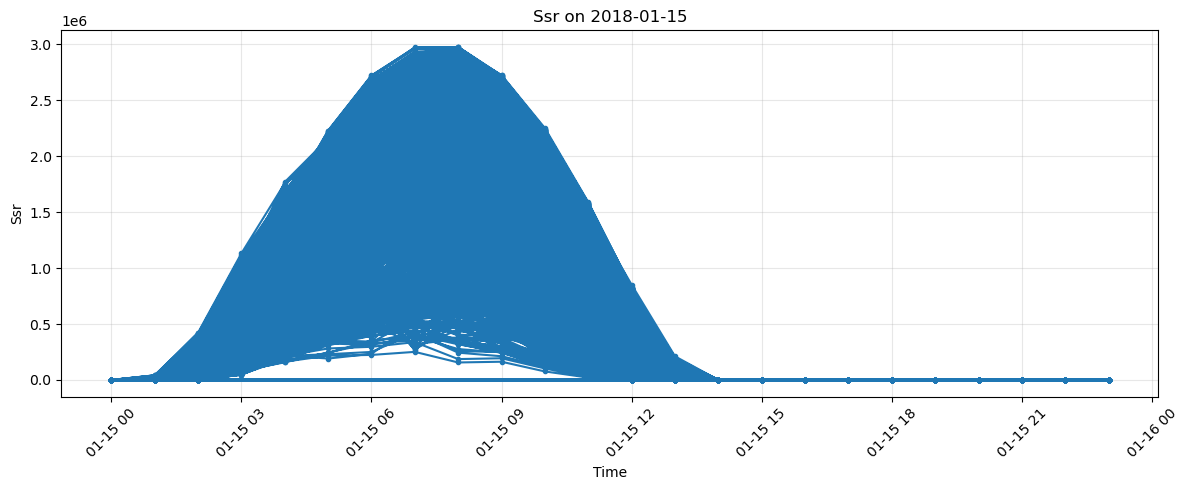

adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,cdir,cvh,cvl,fdir,frac_in_region,hcc,kx,lai_hv,lai_lv,latitude,lcc,longitude,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,t2m,tcc,time,tp,tsr,tsrc,ttr,ttrc,u10,u100,uvb,v10,v100
str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-36.866035,0.0,0.284668,35.25,0.972046,77.5,0.0,3.6000e-12,0.0,0.0,0.0,-157811.25,-225859.5625,421205.375,372718.75,241.832947,0.972046,2018-01-15 00:00:00,0.000004,0.0,0.0,-580215.0,-578913.0,0.61496,1.913864,0.0,-0.352936,1.43219
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-35.825348,0.0,0.284668,35.25,0.974152,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-162705.125,-214641.9375,408939.25,373661.9375,241.79158,0.974152,2018-01-15 01:00:00,0.000003,0.0,0.0,-575022.0,-573343.0,0.591339,1.70842,0.0,-0.286331,1.734161
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.0,0.0,0.005654,0.0,1.0,0.0,-34.497498,0.0,0.284668,35.25,0.854095,77.5,0.000702,3.6000e-12,0.0,0.0,0.0,-156233.4375,-204176.375,412409.9375,375943.5625,241.885132,0.854095,2018-01-15 02:00:00,0.000002,0.0,0.0,-572226.0,-568834.0,0.626221,1.671066,0.0,-0.147141,1.995972
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",195968.0,0.0,0.005654,162112.0,1.0,0.0,-33.316917,0.0,0.284668,35.25,0.864075,77.5,0.001373,56960.0,62016.0,263360.0,276608.0,-163973.3125,-199126.125,410291.0,378653.9375,241.973267,0.864777,2018-01-15 03:00:00,0.000002,157184.0,160768.0,-572073.0,-567374.0,0.616745,1.683121,26768.0,-0.111084,2.038452
"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",826816.0,0.0,0.005654,777152.0,1.0,0.0,-32.895897,0.0,0.284668,35.25,0.837189,77.5,0.003448,213312.0,234432.0,1.008704e6,1.01952e6,-208546.5,-223967.5,403773.125,383083.5,241.039505,0.837189,2018-01-15 04:00:00,0.000001,429952.0,448896.0,-589513.0,-583209.0,0.581116,1.781586,104960.0,-0.021484,2.215454
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.865875,12.092262,1.013184,0.787109,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-297672.0,-309725.0,1.3030e6,1306814.5,297.973267,0.865875,2018-01-15 19:00:00,0.0,0.0,0.0,-1.05832e6,-1.063787e6,-3.132797,-4.544662,0.0,-5.315994,-7.413864
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,0.995697,12.584808,1.013184,0.786987,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-291130.0,-309602.0,1.3064e6,1.307694e6,297.305817,0.995697,2018-01-15 20:00:00,0.0,0.0,0.0,-1.049469e6,-1.061955e6,-2.842056,-4.116135,0.0,-5.483734,-7.636276
"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B52639434516056""","""Tirunelveli""",0.0,0.031433,0.958844,0.0,1.0,1.0,13.226654,1.013184,0.786987,8.25,0.0,77.75,0.0,3.6000e-12,0.0,0.0,0.0,-268272.0,-304450.0,1326373.5,1.3100e6,297.066467,1.0,2018-01-15 21:00:00,0.0,0.0,0.0,-1.042689e6,-1.058559e6,-2.333893,-3.379288,0.0,-5.535385,-7.742966


In [120]:
plot_day_polars_direct(step3_consolidated_data_2018_pldf, date='2018-01-15', column='ssr')

##### Step 4 Data

In [121]:
# Describe
print('Step 4 Interpolated Data 2018 Description')
display(step4_interpolated_data_2018_pldf.describe())

Step 4 Interpolated Data 2018 Description


statistic,latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
str,f64,f64,str,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.918944e7,1.918944e7,"""19189440""",1.918944e7,"""19189440""","""19189440""","""19189440""","""19189440""","""19189440""","""19189440""",1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.918944e7
"""null_count""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""",8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,0.0
"""mean""",22.886875,79.613518,"""2018-02-14 23:45:00""",1.0,null,null,null,null,null,null,0.001083,-0.335314,-0.040832,-0.589014,293.538452,0.245902,0.152519,0.09468,0.056549,1.006693,0.279998,0.663284,1.744957,1.616609,329818.09375,353240.15625,409581.375,438183.5625,-162173.5625,-174018.84375,596346.1875,583617.8125,469611.875,492716.59375,-497292.59375,-512413.46875,357306.53125,315705.78125,45351.734375,0.000012
"""std""",5.504276,5.880583,null,0.0,null,null,null,null,null,null,1.780833,1.433054,2.978337,2.443955,10.731528,0.338999,0.299508,0.203338,0.177783,22.336269,0.31615,0.325827,1.218899,0.710154,459316.3125,483662.09375,558975.375,587195.375,72073.617188,64245.375,91369.875,94008.164062,626015.5625,651932.125,64513.71875,48532.058594,493823.5,456978.625,62990.632812,0.000091
"""min""",8.25,68.25,"""2018-01-01 00:00:00""",1.0,"""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",-9.442978,-8.479828,-12.397232,-12.099319,229.620056,0.0,0.0,0.0,0.0,-117.629463,0.0,0.0,0.0,0.0,1.2529e-28,0.0,0.0,0.0,-6.770208e6,-548308.875,126016.421875,120702.429688,0.0,0.0,-723336.25,-718765.1875,0.0,0.0,0.0,0.0
"""25%""",19.5,75.5,"""2018-01-23 12:00:00""",1.0,null,null,null,null,null,null,-1.237854,-1.348312,-1.978775,-2.171555,289.478912,0.0,0.0,0.0,0.0,-16.999634,0.00238,0.416563,0.971924,1.130371,1.2090e-13,0.0,0.0,0.0,-206660.734375,-214162.515625,556196.0,549256.75,0.0,0.0,-535115.25,-539544.0,0.0,0.0,0.0,0.0
"""50%""",23.5,78.25,"""2018-02-15 00:00:00""",1.0,null,null,null,null,null,null,-0.086327,-0.406937,-0.118973,-0.623955,295.152527,0.035004,0.0,0.0,0.0,4.430061,0.149811,0.755631,1.880859,1.571533,232.250259,255.467545,313.196777,319.437378,-141632.640625,-150117.171875,605757.0625,597765.4375,802.506165,856.970154,-511080.53125,-517323.4375,3.443002,0.334262,47.742352,0.0
"""75%""",26.75,82.5,"""2018-03-09 11:30:00""",1.0,null,null,null,null,null,null,1.223862,0.619217,1.862091,0.924744,300.184479,0.427368,0.101746,0.075562,0.0,20.575081,0.504298,0.976124,2.294556,2.14563,669291.9375,745709.125,858085.75,956958.4375,-115135.75,-126586.015625,653099.4375,641537.8125,984407.3125,1.0532e6,-479829.125,-493858.0,770224.3125,620099.5,92759.875,0.0
"""max""",35.25,97.25,"""2018-03-31 23:30:00""",1.0,"""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",9.615158,8.422836,12.165634,11.412628,317.553223,1.0,1.0,1.0,1.0,43.424789,1.0,1.0,6.289917,3.686157,1.755921e6,1765405.5,2.0804e6,2.0033e6,6.765892e6,-42481.765625,987563.0625,923529.0625,2320033.5,2.2505e6,-154036.296875,-175915.546875,1.7650e6,1819123.5,253438.375,0.010661


In [122]:
print('Step 4 Interpolated Data 2018 — First 8 rows:')
display(step4_interpolated_data_2018_pldf.head(8))
print('Step 4 Interpolated Data 2018 — Last 8 rows:')
display(step4_interpolated_data_2018_pldf.tail(8))

Step 4 Interpolated Data 2018 — First 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-01 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.143936,-1.499603,-0.339081,-1.808823,296.919067,0.685303,0.679626,0.00946,0.025208,23.215073,0.611776,0.388224,2.009766,2.217529,6.1480e-14,0.0,0.0,0.0,-69101.445312,-76225.757812,455355.25,456939.84375,0.0,0.0,-339573.40625,-343621.1875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.148972,-1.54351,-0.316956,-1.792931,296.855988,0.486664,0.462158,0.021362,0.041428,22.438404,0.611776,0.388224,2.009766,2.21759,1.2296e-13,0.0,0.0,0.0,-137434.5625,-152428.75,910464.9375,913092.125,0.0,0.0,-679577.625,-686863.75,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.154007,-1.587418,-0.29483,-1.777039,296.792908,0.288025,0.24469,0.033264,0.057648,21.661736,0.611776,0.388224,2.009766,2.217651,2.0540e-28,0.0,0.0,0.0,-100882.03125,-114266.335938,683081.5625,684007.5,0.0,0.0,-510002.96875,-514648.96875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.218918,-1.493935,-0.366295,-1.719696,297.284882,0.3228,0.296631,0.020416,0.0336,21.0975,0.611776,0.388224,2.009827,2.217651,3.6000e-12,0.0,0.0,0.0,-102592.03125,-114297.101562,681756.75,682876.25,0.0,0.0,-510872.03125,-514322.0625,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.283829,-1.400452,-0.437759,-1.662354,297.776855,0.357574,0.348572,0.007568,0.009552,20.533264,0.611776,0.388224,2.009888,2.217651,34734.046875,29724.925781,40621.679688,39879.859375,-103284.507812,-112274.234375,678484.3125,681798.9375,76438.648438,71432.578125,-510809.84375,-513926.0625,20135.501953,20534.251953,4512.660645,0.0
8.25,77.25,2018-01-01 02:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.300034,-1.182655,-0.402771,-1.424461,298.161194,0.312195,0.286743,0.022079,0.035721,20.340279,0.611776,0.388224,2.009888,2.217712,133521.953125,124259.078125,154258.328125,153656.140625,-112500.609375,-116544.390625,680275.5625,682199.9375,252137.359375,244727.421875,-512977.125,-514814.90625,92120.492188,92169.75,16615.339844,0.0
8.25,77.25,2018-01-01 03:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.316238,-0.964859,-0.367783,-1.186569,298.545532,0.266815,0.224915,0.036591,0.06189,20.147293,0.611776,0.388224,2.009888,2.217773,274397.0625,278217.59375,314429.53125,318833.21875,-119514.164062,-121729.78125,683962.9375,682805.1875,454603.96875,459147.90625,-514625.4375,-515843.875,220055.890625,215257.15625,31988.390625,0.0
8.25,77.25,2018-01-01 03:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.21563,-0.85746,-0.261841,-1.069206,298.897827,0.300873,0.271591,0.027573,0.052383,20.151382,0.611776,0.388224,2.009949,2.217773,523170.9375,537974.375,594178.4375,601422.75,-134206.828125,-130031.210938,690456.9375,686219.6875,804148.0625,819188.0625,-517820.59375,-517872.125,448808.09375,440038.84375,62451.613281,0.0


Step 4 Interpolated Data 2018 — Last 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
35.25,78.0,2018-03-31 20:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.525284,0.232193,0.894547,1.621445,252.837418,0.0,0.0,0.0,0.0,-45.744987,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-111012.78125,-109222.804688,228592.203125,228186.5625,0.0,0.0,-318986.71875,-317858.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 20:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.546562,0.241219,0.933342,1.651146,252.558441,0.004471,0.0,0.0,0.004471,-44.253738,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107632.210938,-105612.195312,229201.828125,228646.375,0.0,0.0,-317256.3125,-315918.53125,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.567841,0.250244,0.972137,1.680847,252.279449,0.008942,0.0,0.0,0.008942,-42.762489,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107196.21875,-104644.976562,228613.5625,228862.59375,0.0,0.0,-316497.65625,-315503.96875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.648216,0.275894,0.868614,1.829506,251.699448,0.01683,0.0,0.0,0.01683,-41.22118,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-102665.773438,-101598.023438,231048.578125,229432.015625,0.0,0.0,-315718.34375,-314026.0,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.728592,0.301544,0.765091,1.978165,251.119446,0.024719,0.0,0.0,0.024719,-39.679871,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-99564.609375,-100357.890625,233980.921875,229638.828125,0.0,0.0,-316313.09375,-313411.9375,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.721428,0.26841,0.836044,1.945374,250.690338,0.056931,0.0,0.0,0.056931,-38.349304,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-95057.390625,-98213.109375,236849.078125,230231.171875,0.0,0.0,-315768.9375,-312481.0625,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 23:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0
35.25,78.0,2018-03-31 23:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0


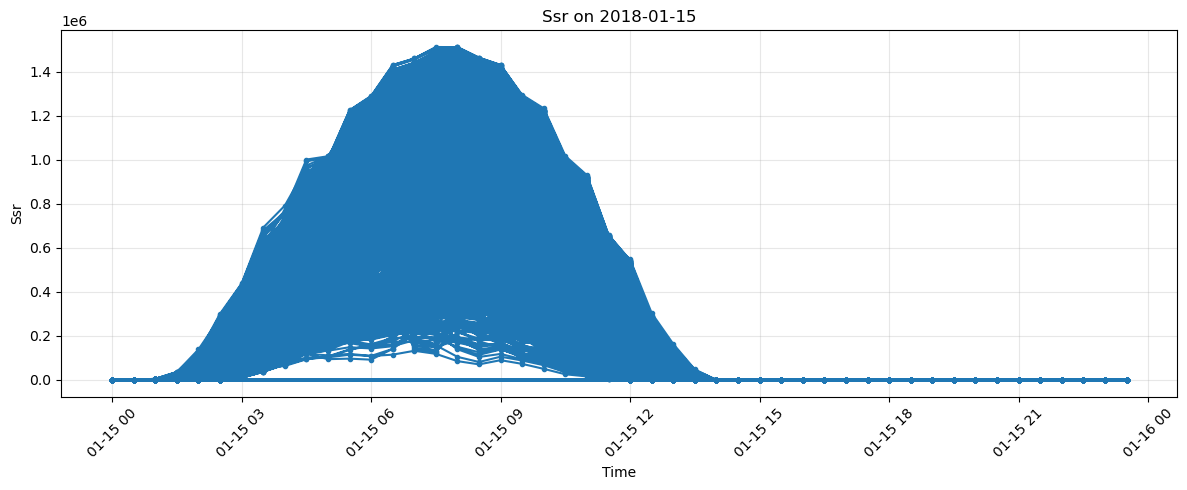

latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-15 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.693634,-0.955475,-3.824417,-2.104919,297.192322,0.015228,0.0,0.0,0.015228,10.075371,0.611776,0.388224,2.026245,2.22937,1.2090e-13,0.0,0.0,0.0,-110911.09375,-140621.390625,674713.125,658792.375,0.0,0.0,-524939.125,-526919.9375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.732788,-1.061333,-3.814346,-2.234207,297.279053,0.077164,0.0,0.0,0.077164,10.307629,0.611776,0.388224,2.026184,2.22937,1.2090e-13,0.0,0.0,0.0,-100788.15625,-142102.171875,686044.3125,658470.375,0.0,0.0,-524699.875,-526793.0,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.771942,-1.167191,-3.804276,-2.363495,297.365784,0.139099,0.0,0.0,0.139099,10.539886,0.611776,0.388224,2.026123,2.22937,2.8081e-28,0.0,0.0,0.0,-89386.476562,-142717.828125,698714.125,658066.375,0.0,0.0,-524236.125,-526734.4375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.770615,-1.333435,-3.683792,-2.50798,297.519012,0.151718,0.0,0.0,0.151718,10.304398,0.611776,0.388224,2.026123,2.22937,3.6000e-12,0.0,0.0,0.0,-89558.648438,-146020.125,699793.125,656011.625,0.0,0.0,-524753.8125,-527184.5,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.769287,-1.49968,-3.563309,-2.652466,297.672241,0.164337,0.0,0.0,0.164337,10.068909,0.611776,0.388224,2.026123,2.22937,23338.603516,22736.205078,27255.773438,30551.970703,-98980.273438,-147485.515625,687417.125,654821.3125,56150.875,54743.953125,-525330.375,-527511.1875,14664.990234,13048.165039,2829.795898,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35.25,78.0,2018-01-15 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.105476,1.539131,1.606201,4.357491,243.482849,0.014771,0.0,0.0,0.014771,-37.298222,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-78212.578125,-75887.8125,192833.265625,191643.75,0.0,0.0,-274083.28125,-272132.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.028397,1.451538,1.369034,4.264587,243.010529,0.022675,0.0,0.0,0.022675,-36.944191,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-77570.648438,-75580.265625,192710.09375,191812.875,0.0,0.0,-273951.3125,-272155.6875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.05336,1.426369,1.321899,4.194954,242.844635,0.028854,0.0,0.0,0.028854,-36.601288,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-75330.242188,-73935.164062,192593.515625,192066.125,0.0,0.0,-272921.65625,-271620.3125,0.0,0.0,0.0,0.0


In [123]:
plot_day_polars_direct(step4_interpolated_data_2018_pldf, date='2018-01-15', column='ssr')

##### Step 5 Data: 

In [124]:
# Describe
print('Step 5 Interpolated Boundary Fixed Data 2018 Description')
display(step5_interpolated_boundary_fixed_data_2018_pldf.describe())

Step 5 Interpolated Boundary Fixed Data 2018 Description


statistic,latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
str,f64,f64,str,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.918944e7,1.918944e7,"""19189440""",1.918944e7,"""19189440""","""19189440""","""19189440""","""19189440""","""19189440""","""19189440""",1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.918944e7
"""null_count""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""",8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,0.0
"""mean""",22.886875,79.613518,"""2018-02-14 23:45:00""",1.0,null,null,null,null,null,null,0.001083,-0.335314,-0.040832,-0.589014,293.538452,0.245902,0.152519,0.09468,0.056549,1.006693,0.279998,0.663284,1.744957,1.616609,329818.09375,353240.15625,409581.375,438183.5625,-162173.5625,-174018.84375,596346.1875,583617.8125,469611.875,492716.59375,-497292.59375,-512413.46875,357306.53125,315705.78125,45351.734375,0.000012
"""std""",5.504276,5.880583,null,0.0,null,null,null,null,null,null,1.780833,1.433054,2.978337,2.443955,10.731528,0.338999,0.299508,0.203338,0.177783,22.336269,0.31615,0.325827,1.218899,0.710154,459316.3125,483662.09375,558975.375,587195.375,72073.617188,64245.375,91369.875,94008.164062,626015.5625,651932.125,64513.71875,48532.058594,493823.5,456978.625,62990.632812,0.000091
"""min""",8.25,68.25,"""2018-01-01 00:00:00""",1.0,"""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",-9.442978,-8.479828,-12.397232,-12.099319,229.620056,0.0,0.0,0.0,0.0,-117.629463,0.0,0.0,0.0,0.0,1.2529e-28,0.0,0.0,0.0,-6.770208e6,-548308.875,126016.421875,120702.429688,0.0,0.0,-723336.25,-718765.1875,0.0,0.0,0.0,0.0
"""25%""",19.5,75.5,"""2018-01-23 12:00:00""",1.0,null,null,null,null,null,null,-1.237854,-1.348312,-1.978775,-2.171555,289.478912,0.0,0.0,0.0,0.0,-16.999634,0.00238,0.416563,0.971924,1.130371,1.2090e-13,0.0,0.0,0.0,-206660.734375,-214162.515625,556196.0,549256.75,0.0,0.0,-535115.25,-539544.0,0.0,0.0,0.0,0.0
"""50%""",23.5,78.25,"""2018-02-15 00:00:00""",1.0,null,null,null,null,null,null,-0.086327,-0.406937,-0.118973,-0.623955,295.152527,0.035004,0.0,0.0,0.0,4.430061,0.149811,0.755631,1.880859,1.571533,232.250259,255.467545,313.196777,319.437378,-141632.640625,-150117.171875,605757.0625,597765.4375,802.506165,856.970154,-511080.53125,-517323.4375,3.443002,0.334262,47.742352,0.0
"""75%""",26.75,82.5,"""2018-03-09 11:30:00""",1.0,null,null,null,null,null,null,1.223862,0.619217,1.862091,0.924744,300.184479,0.427368,0.101746,0.075562,0.0,20.575081,0.504298,0.976124,2.294556,2.14563,669291.9375,745709.125,858085.75,956958.4375,-115135.75,-126586.015625,653099.4375,641537.8125,984407.3125,1.0532e6,-479829.125,-493858.0,770224.3125,620099.5,92759.875,0.0
"""max""",35.25,97.25,"""2018-03-31 23:30:00""",1.0,"""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",9.615158,8.422836,12.165634,11.412628,317.553223,1.0,1.0,1.0,1.0,43.424789,1.0,1.0,6.289917,3.686157,1.755921e6,1765405.5,2.0804e6,2.0033e6,6.765892e6,-42481.765625,987563.0625,923529.0625,2320033.5,2.2505e6,-154036.296875,-175915.546875,1.7650e6,1819123.5,253438.375,0.010661


In [125]:
print('Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.tail(8))

Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-01 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.143936,-1.499603,-0.339081,-1.808823,296.919067,0.685303,0.679626,0.00946,0.025208,23.215073,0.611776,0.388224,2.009766,2.217529,6.1480e-14,0.0,0.0,0.0,-69101.445312,-76225.757812,455355.25,456939.84375,0.0,0.0,-339573.40625,-343621.1875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.148972,-1.54351,-0.316956,-1.792931,296.855988,0.486664,0.462158,0.021362,0.041428,22.438404,0.611776,0.388224,2.009766,2.21759,1.2296e-13,0.0,0.0,0.0,-137434.5625,-152428.75,910464.9375,913092.125,0.0,0.0,-679577.625,-686863.75,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.154007,-1.587418,-0.29483,-1.777039,296.792908,0.288025,0.24469,0.033264,0.057648,21.661736,0.611776,0.388224,2.009766,2.217651,2.0540e-28,0.0,0.0,0.0,-100882.03125,-114266.335938,683081.5625,684007.5,0.0,0.0,-510002.96875,-514648.96875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.218918,-1.493935,-0.366295,-1.719696,297.284882,0.3228,0.296631,0.020416,0.0336,21.0975,0.611776,0.388224,2.009827,2.217651,3.6000e-12,0.0,0.0,0.0,-102592.03125,-114297.101562,681756.75,682876.25,0.0,0.0,-510872.03125,-514322.0625,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.283829,-1.400452,-0.437759,-1.662354,297.776855,0.357574,0.348572,0.007568,0.009552,20.533264,0.611776,0.388224,2.009888,2.217651,34734.046875,29724.925781,40621.679688,39879.859375,-103284.507812,-112274.234375,678484.3125,681798.9375,76438.648438,71432.578125,-510809.84375,-513926.0625,20135.501953,20534.251953,4512.660645,0.0
8.25,77.25,2018-01-01 02:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.300034,-1.182655,-0.402771,-1.424461,298.161194,0.312195,0.286743,0.022079,0.035721,20.340279,0.611776,0.388224,2.009888,2.217712,133521.953125,124259.078125,154258.328125,153656.140625,-112500.609375,-116544.390625,680275.5625,682199.9375,252137.359375,244727.421875,-512977.125,-514814.90625,92120.492188,92169.75,16615.339844,0.0
8.25,77.25,2018-01-01 03:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.316238,-0.964859,-0.367783,-1.186569,298.545532,0.266815,0.224915,0.036591,0.06189,20.147293,0.611776,0.388224,2.009888,2.217773,274397.0625,278217.59375,314429.53125,318833.21875,-119514.164062,-121729.78125,683962.9375,682805.1875,454603.96875,459147.90625,-514625.4375,-515843.875,220055.890625,215257.15625,31988.390625,0.0
8.25,77.25,2018-01-01 03:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.21563,-0.85746,-0.261841,-1.069206,298.897827,0.300873,0.271591,0.027573,0.052383,20.151382,0.611776,0.388224,2.009949,2.217773,523170.9375,537974.375,594178.4375,601422.75,-134206.828125,-130031.210938,690456.9375,686219.6875,804148.0625,819188.0625,-517820.59375,-517872.125,448808.09375,440038.84375,62451.613281,0.0


Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
35.25,78.0,2018-03-31 20:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.525284,0.232193,0.894547,1.621445,252.837418,0.0,0.0,0.0,0.0,-45.744987,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-111012.78125,-109222.804688,228592.203125,228186.5625,0.0,0.0,-318986.71875,-317858.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 20:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.546562,0.241219,0.933342,1.651146,252.558441,0.004471,0.0,0.0,0.004471,-44.253738,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107632.210938,-105612.195312,229201.828125,228646.375,0.0,0.0,-317256.3125,-315918.53125,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.567841,0.250244,0.972137,1.680847,252.279449,0.008942,0.0,0.0,0.008942,-42.762489,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107196.21875,-104644.976562,228613.5625,228862.59375,0.0,0.0,-316497.65625,-315503.96875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.648216,0.275894,0.868614,1.829506,251.699448,0.01683,0.0,0.0,0.01683,-41.22118,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-102665.773438,-101598.023438,231048.578125,229432.015625,0.0,0.0,-315718.34375,-314026.0,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.728592,0.301544,0.765091,1.978165,251.119446,0.024719,0.0,0.0,0.024719,-39.679871,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-99564.609375,-100357.890625,233980.921875,229638.828125,0.0,0.0,-316313.09375,-313411.9375,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.721428,0.26841,0.836044,1.945374,250.690338,0.056931,0.0,0.0,0.056931,-38.349304,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-95057.390625,-98213.109375,236849.078125,230231.171875,0.0,0.0,-315768.9375,-312481.0625,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 23:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0
35.25,78.0,2018-03-31 23:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0


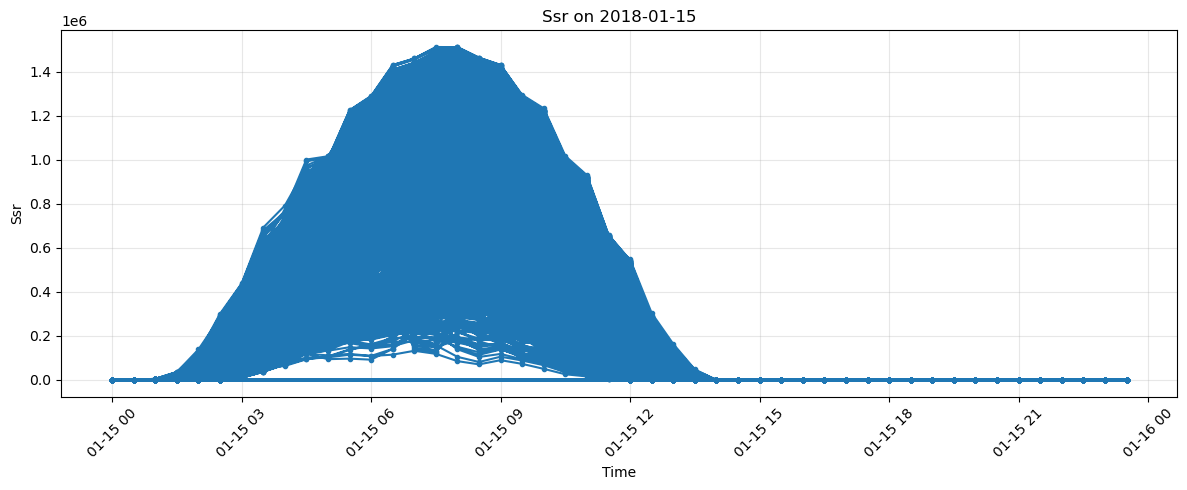

latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-15 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.693634,-0.955475,-3.824417,-2.104919,297.192322,0.015228,0.0,0.0,0.015228,10.075371,0.611776,0.388224,2.026245,2.22937,1.2090e-13,0.0,0.0,0.0,-110911.09375,-140621.390625,674713.125,658792.375,0.0,0.0,-524939.125,-526919.9375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.732788,-1.061333,-3.814346,-2.234207,297.279053,0.077164,0.0,0.0,0.077164,10.307629,0.611776,0.388224,2.026184,2.22937,1.2090e-13,0.0,0.0,0.0,-100788.15625,-142102.171875,686044.3125,658470.375,0.0,0.0,-524699.875,-526793.0,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.771942,-1.167191,-3.804276,-2.363495,297.365784,0.139099,0.0,0.0,0.139099,10.539886,0.611776,0.388224,2.026123,2.22937,2.8081e-28,0.0,0.0,0.0,-89386.476562,-142717.828125,698714.125,658066.375,0.0,0.0,-524236.125,-526734.4375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.770615,-1.333435,-3.683792,-2.50798,297.519012,0.151718,0.0,0.0,0.151718,10.304398,0.611776,0.388224,2.026123,2.22937,3.6000e-12,0.0,0.0,0.0,-89558.648438,-146020.125,699793.125,656011.625,0.0,0.0,-524753.8125,-527184.5,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.769287,-1.49968,-3.563309,-2.652466,297.672241,0.164337,0.0,0.0,0.164337,10.068909,0.611776,0.388224,2.026123,2.22937,23338.603516,22736.205078,27255.773438,30551.970703,-98980.273438,-147485.515625,687417.125,654821.3125,56150.875,54743.953125,-525330.375,-527511.1875,14664.990234,13048.165039,2829.795898,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35.25,78.0,2018-01-15 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.105476,1.539131,1.606201,4.357491,243.482849,0.014771,0.0,0.0,0.014771,-37.298222,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-78212.578125,-75887.8125,192833.265625,191643.75,0.0,0.0,-274083.28125,-272132.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.028397,1.451538,1.369034,4.264587,243.010529,0.022675,0.0,0.0,0.022675,-36.944191,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-77570.648438,-75580.265625,192710.09375,191812.875,0.0,0.0,-273951.3125,-272155.6875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.05336,1.426369,1.321899,4.194954,242.844635,0.028854,0.0,0.0,0.028854,-36.601288,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-75330.242188,-73935.164062,192593.515625,192066.125,0.0,0.0,-272921.65625,-271620.3125,0.0,0.0,0.0,0.0


In [126]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2018_pldf, date='2018-01-15', column='ssr')

##### Step 6 Data:

In [127]:
# Describe
print('Step 6 Interpolated Final Data 2018 Description')
display(step6_interpolated_final_data_2018_pldf.describe())

Step 6 Interpolated Final Data 2018 Description


statistic,latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
str,f64,f64,str,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.918944e7,1.918944e7,"""19189440""",1.918944e7,"""19189440""","""19189440""","""19189440""","""19189440""","""19189440""","""19189440""",1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.9180556e7,1.918944e7
"""null_count""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""",8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,8884.0,0.0
"""mean""",22.886875,79.613518,"""2018-02-14 23:45:00""",1.0,null,null,null,null,null,null,0.001083,-0.335314,-0.040832,-0.589014,293.538452,0.245902,0.152519,0.09468,0.056549,1.006693,0.279998,0.663284,1.744957,1.616609,329818.09375,353240.15625,409581.375,438183.5625,-162173.5625,-174018.84375,596346.1875,583617.8125,469611.875,492716.59375,-497292.59375,-512413.46875,357306.53125,315705.78125,45351.734375,0.000012
"""std""",5.504276,5.880583,null,0.0,null,null,null,null,null,null,1.780833,1.433054,2.978337,2.443955,10.731528,0.338999,0.299508,0.203338,0.177783,22.336269,0.31615,0.325827,1.218899,0.710154,459316.3125,483662.09375,558975.375,587195.375,72073.617188,64245.375,91369.875,94008.164062,626015.5625,651932.125,64513.71875,48532.058594,493823.5,456978.625,62990.632812,0.000091
"""min""",8.25,68.25,"""2018-01-01 00:00:00""",1.0,"""IND""","""India""","""1811400B11231190780494""","""Andhra Pradesh""","""76128533B10727492375508""","""Adilabad""",-9.442978,-8.479828,-12.397232,-12.099319,229.620056,0.0,0.0,0.0,0.0,-117.629463,0.0,0.0,0.0,0.0,1.2529e-28,0.0,0.0,0.0,-6.770208e6,-548308.875,126016.421875,120702.429688,0.0,0.0,-723336.25,-718765.1875,0.0,0.0,0.0,0.0
"""25%""",19.5,75.5,"""2018-01-23 12:00:00""",1.0,null,null,null,null,null,null,-1.237854,-1.348312,-1.978775,-2.171555,289.478912,0.0,0.0,0.0,0.0,-16.999634,0.00238,0.416563,0.971924,1.130371,1.2090e-13,0.0,0.0,0.0,-206660.734375,-214162.515625,556196.0,549256.75,0.0,0.0,-535115.25,-539544.0,0.0,0.0,0.0,0.0
"""50%""",23.5,78.25,"""2018-02-15 00:00:00""",1.0,null,null,null,null,null,null,-0.086327,-0.406937,-0.118973,-0.623955,295.152527,0.035004,0.0,0.0,0.0,4.430061,0.149811,0.755631,1.880859,1.571533,232.250259,255.467545,313.196777,319.437378,-141632.640625,-150117.171875,605757.0625,597765.4375,802.506165,856.970154,-511080.53125,-517323.4375,3.443002,0.334262,47.742352,0.0
"""75%""",26.75,82.5,"""2018-03-09 11:30:00""",1.0,null,null,null,null,null,null,1.223862,0.619217,1.862091,0.924744,300.184479,0.427368,0.101746,0.075562,0.0,20.575081,0.504298,0.976124,2.294556,2.14563,669291.9375,745709.125,858085.75,956958.4375,-115135.75,-126586.015625,653099.4375,641537.8125,984407.3125,1.0532e6,-479829.125,-493858.0,770224.3125,620099.5,92759.875,0.0
"""max""",35.25,97.25,"""2018-03-31 23:30:00""",1.0,"""IND""","""India""","""NONE_DEFINED""","""West Bengal""","""NONE_DEFINED""","""Zunheboto""",9.615158,8.422836,12.165634,11.412628,317.553223,1.0,1.0,1.0,1.0,43.424789,1.0,1.0,6.289917,3.686157,1.755921e6,1765405.5,2.0804e6,2.0033e6,6.765892e6,-42481.765625,987563.0625,923529.0625,2320033.5,2.2505e6,-154036.296875,-175915.546875,1.7650e6,1819123.5,253438.375,0.010661


In [128]:
print('Step 6 Interpolated Final Data 2018 — First 8 rows:')
display(step6_interpolated_final_data_2018_pldf.head(8))
print('Step 6 Interpolated Final Data 2018 — Last 8 rows:')
display(step6_interpolated_final_data_2018_pldf.tail(8))

Step 6 Interpolated Final Data 2018 — First 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-01 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.143936,-1.499603,-0.339081,-1.808823,296.919067,0.685303,0.679626,0.00946,0.025208,23.215073,0.611776,0.388224,2.009766,2.217529,6.1480e-14,0.0,0.0,0.0,-69101.445312,-76225.757812,455355.25,456939.84375,0.0,0.0,-339573.40625,-343621.1875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.148972,-1.54351,-0.316956,-1.792931,296.855988,0.486664,0.462158,0.021362,0.041428,22.438404,0.611776,0.388224,2.009766,2.21759,1.2296e-13,0.0,0.0,0.0,-137434.5625,-152428.75,910464.9375,913092.125,0.0,0.0,-679577.625,-686863.75,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.154007,-1.587418,-0.29483,-1.777039,296.792908,0.288025,0.24469,0.033264,0.057648,21.661736,0.611776,0.388224,2.009766,2.217651,2.0540e-28,0.0,0.0,0.0,-100882.03125,-114266.335938,683081.5625,684007.5,0.0,0.0,-510002.96875,-514648.96875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.218918,-1.493935,-0.366295,-1.719696,297.284882,0.3228,0.296631,0.020416,0.0336,21.0975,0.611776,0.388224,2.009827,2.217651,3.6000e-12,0.0,0.0,0.0,-102592.03125,-114297.101562,681756.75,682876.25,0.0,0.0,-510872.03125,-514322.0625,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.283829,-1.400452,-0.437759,-1.662354,297.776855,0.357574,0.348572,0.007568,0.009552,20.533264,0.611776,0.388224,2.009888,2.217651,34734.046875,29724.925781,40621.679688,39879.859375,-103284.507812,-112274.234375,678484.3125,681798.9375,76438.648438,71432.578125,-510809.84375,-513926.0625,20135.501953,20534.251953,4512.660645,0.0
8.25,77.25,2018-01-01 02:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.300034,-1.182655,-0.402771,-1.424461,298.161194,0.312195,0.286743,0.022079,0.035721,20.340279,0.611776,0.388224,2.009888,2.217712,133521.953125,124259.078125,154258.328125,153656.140625,-112500.609375,-116544.390625,680275.5625,682199.9375,252137.359375,244727.421875,-512977.125,-514814.90625,92120.492188,92169.75,16615.339844,0.0
8.25,77.25,2018-01-01 03:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.316238,-0.964859,-0.367783,-1.186569,298.545532,0.266815,0.224915,0.036591,0.06189,20.147293,0.611776,0.388224,2.009888,2.217773,274397.0625,278217.59375,314429.53125,318833.21875,-119514.164062,-121729.78125,683962.9375,682805.1875,454603.96875,459147.90625,-514625.4375,-515843.875,220055.890625,215257.15625,31988.390625,0.0
8.25,77.25,2018-01-01 03:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.21563,-0.85746,-0.261841,-1.069206,298.897827,0.300873,0.271591,0.027573,0.052383,20.151382,0.611776,0.388224,2.009949,2.217773,523170.9375,537974.375,594178.4375,601422.75,-134206.828125,-130031.210938,690456.9375,686219.6875,804148.0625,819188.0625,-517820.59375,-517872.125,448808.09375,440038.84375,62451.613281,0.0


Step 6 Interpolated Final Data 2018 — Last 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
35.25,78.0,2018-03-31 20:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.525284,0.232193,0.894547,1.621445,252.837418,0.0,0.0,0.0,0.0,-45.744987,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-111012.78125,-109222.804688,228592.203125,228186.5625,0.0,0.0,-318986.71875,-317858.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 20:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.546562,0.241219,0.933342,1.651146,252.558441,0.004471,0.0,0.0,0.004471,-44.253738,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107632.210938,-105612.195312,229201.828125,228646.375,0.0,0.0,-317256.3125,-315918.53125,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.567841,0.250244,0.972137,1.680847,252.279449,0.008942,0.0,0.0,0.008942,-42.762489,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107196.21875,-104644.976562,228613.5625,228862.59375,0.0,0.0,-316497.65625,-315503.96875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.648216,0.275894,0.868614,1.829506,251.699448,0.01683,0.0,0.0,0.01683,-41.22118,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-102665.773438,-101598.023438,231048.578125,229432.015625,0.0,0.0,-315718.34375,-314026.0,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.728592,0.301544,0.765091,1.978165,251.119446,0.024719,0.0,0.0,0.024719,-39.679871,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-99564.609375,-100357.890625,233980.921875,229638.828125,0.0,0.0,-316313.09375,-313411.9375,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.721428,0.26841,0.836044,1.945374,250.690338,0.056931,0.0,0.0,0.056931,-38.349304,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-95057.390625,-98213.109375,236849.078125,230231.171875,0.0,0.0,-315768.9375,-312481.0625,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 23:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0
35.25,78.0,2018-03-31 23:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0


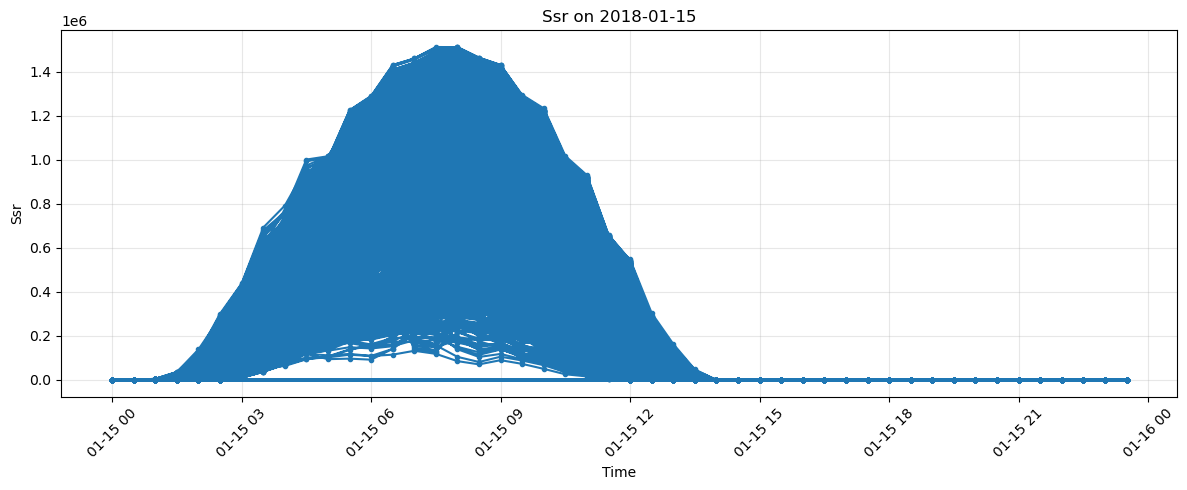

latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-15 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.693634,-0.955475,-3.824417,-2.104919,297.192322,0.015228,0.0,0.0,0.015228,10.075371,0.611776,0.388224,2.026245,2.22937,1.2090e-13,0.0,0.0,0.0,-110911.09375,-140621.390625,674713.125,658792.375,0.0,0.0,-524939.125,-526919.9375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.732788,-1.061333,-3.814346,-2.234207,297.279053,0.077164,0.0,0.0,0.077164,10.307629,0.611776,0.388224,2.026184,2.22937,1.2090e-13,0.0,0.0,0.0,-100788.15625,-142102.171875,686044.3125,658470.375,0.0,0.0,-524699.875,-526793.0,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.771942,-1.167191,-3.804276,-2.363495,297.365784,0.139099,0.0,0.0,0.139099,10.539886,0.611776,0.388224,2.026123,2.22937,2.8081e-28,0.0,0.0,0.0,-89386.476562,-142717.828125,698714.125,658066.375,0.0,0.0,-524236.125,-526734.4375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.770615,-1.333435,-3.683792,-2.50798,297.519012,0.151718,0.0,0.0,0.151718,10.304398,0.611776,0.388224,2.026123,2.22937,3.6000e-12,0.0,0.0,0.0,-89558.648438,-146020.125,699793.125,656011.625,0.0,0.0,-524753.8125,-527184.5,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.769287,-1.49968,-3.563309,-2.652466,297.672241,0.164337,0.0,0.0,0.164337,10.068909,0.611776,0.388224,2.026123,2.22937,23338.603516,22736.205078,27255.773438,30551.970703,-98980.273438,-147485.515625,687417.125,654821.3125,56150.875,54743.953125,-525330.375,-527511.1875,14664.990234,13048.165039,2829.795898,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35.25,78.0,2018-01-15 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.105476,1.539131,1.606201,4.357491,243.482849,0.014771,0.0,0.0,0.014771,-37.298222,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-78212.578125,-75887.8125,192833.265625,191643.75,0.0,0.0,-274083.28125,-272132.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.028397,1.451538,1.369034,4.264587,243.010529,0.022675,0.0,0.0,0.022675,-36.944191,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-77570.648438,-75580.265625,192710.09375,191812.875,0.0,0.0,-273951.3125,-272155.6875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.05336,1.426369,1.321899,4.194954,242.844635,0.028854,0.0,0.0,0.028854,-36.601288,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-75330.242188,-73935.164062,192593.515625,192066.125,0.0,0.0,-272921.65625,-271620.3125,0.0,0.0,0.0,0.0


In [129]:
plot_day_polars_direct(step6_interpolated_final_data_2018_pldf, date='2018-01-15', column='ssr')

##### Step 7 Data:

In [ ]:
step7_processed_data_2018_pldf = pl.read_parquet(source=step7_processed_data_2018_path)

In [130]:
# Describe
print('Step 7 Processed Data 2018 Description')
display(step7_processed_data_2018_pldf.describe())

Step 7 Processed Data 2018 Description


statistic,time,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr_avg,ssr_total,ssrc_avg,ssrc_total,ssrd_avg,ssrd_total,ssrdc_avg,ssrdc_total,str_avg,str_total,strc_avg,strc_total,strd_avg,strd_total,strdc_avg,strdc_total,tsr_avg,tsr_total,tsrc_avg,tsrc_total,ttr_avg,ttr_total,ttrc_avg,ttrc_total,cdir_avg,cdir_total,fdir_avg,fdir_total,uvb_avg,uvb_total,tp_avg,tp_total,wind_10m_speed,wind_10m_dir_deg,wind_100m_speed,wind_100m_dir_deg
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""4320""",4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0,4320.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2018-02-14 23:45:00""",-0.015315,-0.329214,-0.070613,-0.579174,293.659698,0.245332,0.153197,0.093394,0.055225,1.155082,0.28261,0.661743,1.753866,1.623087,331654.6875,1.3510e9,355095.75,1.4464e9,410483.1875,1.6721e9,439007.25,1.7882e9,-162446.9375,-6.6171e8,-174080.984375,-7.0910e8,598400.875,2.4375e9,585867.375,2.3865e9,471966.46875,1.9225e9,495127.59375,2.0168e9,-498209.0,-2.0294e9,-513290.25,-2.0908e9,357929.59375,1.4580e9,316588.46875,1.2896e9,45453.511719,1.85149056e8,0.000011,0.04624,0.694158,158.719757,1.205652,166.00444
"""std""",null,0.542517,0.419188,0.905872,0.740302,8.414896,0.14931,0.147267,0.069189,0.031398,15.575339,0.006083,0.014243,0.046743,0.046493,440926.8125,1.7961e9,470912.09375,1.9182e9,545681.125,2.2228e9,580766.1875,2.3657e9,56786.808594,2.31313808e8,55518.421875,2.26147184e8,42703.5,1.73947248e8,40822.289062,1.66284368e8,608710.625,2.4795e9,637600.5,2.5972e9,33672.0625,1.37158832e8,26345.796875,1.07316232e8,487985.9375,1.9877e9,436639.125,1.7786e9,61561.632812,2.5076344e8,0.000015,0.060301,0.310995,127.310852,0.505198,127.197853
"""min""","""2018-01-01 00:00:00""",-1.290666,-1.359942,-2.242899,-2.258142,0.0,0.0,0.0,0.0,0.0,-31.804468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-309404.28125,-1.2603e9,-316614.21875,-1.2897e9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-632823.5,-2.5777e9,-642873.25,-2.6187e9,0.0,0.0,0.0,0.0,0.0,0.0,5.9713e-8,0.000243,0.0,0.011597,0.0,0.05835
"""25%""","""2018-01-23 12:00:00""",-0.413622,-0.635513,-0.778483,-1.1259,289.225464,0.150754,0.054298,0.047503,0.032336,-14.434318,0.282741,0.662049,1.726371,1.603896,1.2090e-13,4.9245e-10,0.0,0.0,0.0,0.0,0.0,0.0,-212949.109375,-8.6742e8,-226710.359375,-9.2348e8,568672.0,2.3164e9,557228.6875,2.2698e9,0.0,0.0,0.0,0.0,-517947.90625,-2.1098e9,-531003.625,-2.1630e9,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.009792,0.489007,38.939606,0.845374,44.040314
"""50%""","""2018-02-15 00:00:00""",-0.101078,-0.364462,-0.148749,-0.589086,293.737213,0.208933,0.115441,0.076326,0.050156,6.565648,0.282741,0.662049,1.755693,1.631411,10114.074219,4.1198388e7,10225.564453,4.1652528e7,12522.097656,5.1007164e7,13677.920898,5.571526e7,-132767.25,-5.4081e8,-142954.046875,-5.8231e8,597805.4375,2.4351e9,584627.4375,2.3814e9,22132.677734,9.0154632e7,23301.787109,9.4916848e7,-498858.84375,-2.0320e9,-508323.5625,-2.0706e9,6314.433594,2.5721038e7,5003.492676,2.0381088e7,1359.960938,5.539627e6,0.000006,0.02511,0.659378,107.306122,1.187766,123.930969
"""75%""","""2018-03-09 11:30:00""",0.326021,-0.0588,0.615939,-0.105941,297.393616,0.285086,0.193844,0.117561,0.071164,14.77595,0.282741,0.662049,1.777946,1.647439,713509.4375,2.9064e9,773464.625,3.1506e9,884942.125,3.6047e9,953206.875,3.8828e9,-118325.125,-4.8198e8,-129138.148438,-5.260

In [ ]:
print('Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.head(8))
print('Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:')
display(step5_interpolated_boundary_fixed_data_2018_pldf.tail(8))

Step 5 Interpolated Boundary Fixed Data 2018 — First 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-01 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.143936,-1.499603,-0.339081,-1.808823,296.919067,0.685303,0.679626,0.00946,0.025208,23.215073,0.611776,0.388224,2.009766,2.217529,6.1480e-14,0.0,0.0,0.0,-69101.445312,-76225.757812,455355.25,456939.84375,0.0,0.0,-339573.40625,-343621.1875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.148972,-1.54351,-0.316956,-1.792931,296.855988,0.486664,0.462158,0.021362,0.041428,22.438404,0.611776,0.388224,2.009766,2.21759,1.2296e-13,0.0,0.0,0.0,-137434.5625,-152428.75,910464.9375,913092.125,0.0,0.0,-679577.625,-686863.75,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.154007,-1.587418,-0.29483,-1.777039,296.792908,0.288025,0.24469,0.033264,0.057648,21.661736,0.611776,0.388224,2.009766,2.217651,2.0540e-28,0.0,0.0,0.0,-100882.03125,-114266.335938,683081.5625,684007.5,0.0,0.0,-510002.96875,-514648.96875,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.218918,-1.493935,-0.366295,-1.719696,297.284882,0.3228,0.296631,0.020416,0.0336,21.0975,0.611776,0.388224,2.009827,2.217651,3.6000e-12,0.0,0.0,0.0,-102592.03125,-114297.101562,681756.75,682876.25,0.0,0.0,-510872.03125,-514322.0625,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-01 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.283829,-1.400452,-0.437759,-1.662354,297.776855,0.357574,0.348572,0.007568,0.009552,20.533264,0.611776,0.388224,2.009888,2.217651,34734.046875,29724.925781,40621.679688,39879.859375,-103284.507812,-112274.234375,678484.3125,681798.9375,76438.648438,71432.578125,-510809.84375,-513926.0625,20135.501953,20534.251953,4512.660645,0.0
8.25,77.25,2018-01-01 02:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.300034,-1.182655,-0.402771,-1.424461,298.161194,0.312195,0.286743,0.022079,0.035721,20.340279,0.611776,0.388224,2.009888,2.217712,133521.953125,124259.078125,154258.328125,153656.140625,-112500.609375,-116544.390625,680275.5625,682199.9375,252137.359375,244727.421875,-512977.125,-514814.90625,92120.492188,92169.75,16615.339844,0.0
8.25,77.25,2018-01-01 03:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.316238,-0.964859,-0.367783,-1.186569,298.545532,0.266815,0.224915,0.036591,0.06189,20.147293,0.611776,0.388224,2.009888,2.217773,274397.0625,278217.59375,314429.53125,318833.21875,-119514.164062,-121729.78125,683962.9375,682805.1875,454603.96875,459147.90625,-514625.4375,-515843.875,220055.890625,215257.15625,31988.390625,0.0
8.25,77.25,2018-01-01 03:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-0.21563,-0.85746,-0.261841,-1.069206,298.897827,0.300873,0.271591,0.027573,0.052383,20.151382,0.611776,0.388224,2.009949,2.217773,523170.9375,537974.375,594178.4375,601422.75,-134206.828125,-130031.210938,690456.9375,686219.6875,804148.0625,819188.0625,-517820.59375,-517872.125,448808.09375,440038.84375,62451.613281,0.0


Step 5 Interpolated Boundary Fixed Data 2018 — Last 8 rows:


latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
35.25,78.0,2018-03-31 20:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.525284,0.232193,0.894547,1.621445,252.837418,0.0,0.0,0.0,0.0,-45.744987,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-111012.78125,-109222.804688,228592.203125,228186.5625,0.0,0.0,-318986.71875,-317858.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 20:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.546562,0.241219,0.933342,1.651146,252.558441,0.004471,0.0,0.0,0.004471,-44.253738,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107632.210938,-105612.195312,229201.828125,228646.375,0.0,0.0,-317256.3125,-315918.53125,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.567841,0.250244,0.972137,1.680847,252.279449,0.008942,0.0,0.0,0.008942,-42.762489,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-107196.21875,-104644.976562,228613.5625,228862.59375,0.0,0.0,-316497.65625,-315503.96875,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.648216,0.275894,0.868614,1.829506,251.699448,0.01683,0.0,0.0,0.01683,-41.22118,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-102665.773438,-101598.023438,231048.578125,229432.015625,0.0,0.0,-315718.34375,-314026.0,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.728592,0.301544,0.765091,1.978165,251.119446,0.024719,0.0,0.0,0.024719,-39.679871,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-99564.609375,-100357.890625,233980.921875,229638.828125,0.0,0.0,-316313.09375,-313411.9375,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.721428,0.26841,0.836044,1.945374,250.690338,0.056931,0.0,0.0,0.056931,-38.349304,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-95057.390625,-98213.109375,236849.078125,230231.171875,0.0,0.0,-315768.9375,-312481.0625,0.0,0.0,0.0,0.0
35.25,78.0,2018-03-31 23:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0
35.25,78.0,2018-03-31 23:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0


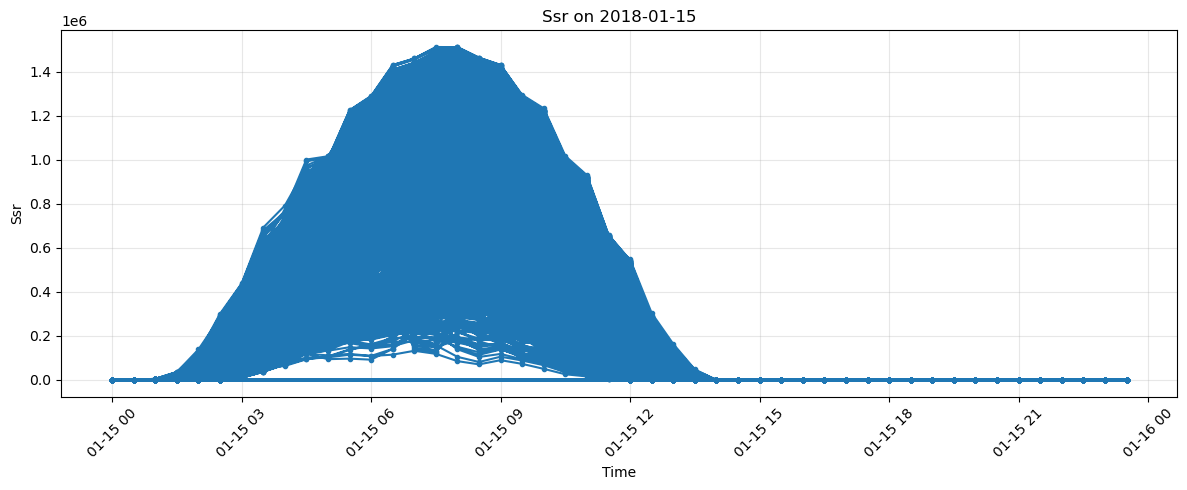

latitude,longitude,time,frac_in_region,adm0_code,adm0_name,adm1_code,adm1_name,adm2_code,adm2_name,u10,v10,u100,v100,t2m,tcc,hcc,mcc,lcc,kx,cvh,cvl,lai_hv,lai_lv,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tsr,tsrc,ttr,ttrc,cdir,fdir,uvb,tp
f32,f32,datetime[μs],f32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
8.25,77.25,2018-01-15 00:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.693634,-0.955475,-3.824417,-2.104919,297.192322,0.015228,0.0,0.0,0.015228,10.075371,0.611776,0.388224,2.026245,2.22937,1.2090e-13,0.0,0.0,0.0,-110911.09375,-140621.390625,674713.125,658792.375,0.0,0.0,-524939.125,-526919.9375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 00:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.732788,-1.061333,-3.814346,-2.234207,297.279053,0.077164,0.0,0.0,0.077164,10.307629,0.611776,0.388224,2.026184,2.22937,1.2090e-13,0.0,0.0,0.0,-100788.15625,-142102.171875,686044.3125,658470.375,0.0,0.0,-524699.875,-526793.0,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.771942,-1.167191,-3.804276,-2.363495,297.365784,0.139099,0.0,0.0,0.139099,10.539886,0.611776,0.388224,2.026123,2.22937,2.8081e-28,0.0,0.0,0.0,-89386.476562,-142717.828125,698714.125,658066.375,0.0,0.0,-524236.125,-526734.4375,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 01:30:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.770615,-1.333435,-3.683792,-2.50798,297.519012,0.151718,0.0,0.0,0.151718,10.304398,0.611776,0.388224,2.026123,2.22937,3.6000e-12,0.0,0.0,0.0,-89558.648438,-146020.125,699793.125,656011.625,0.0,0.0,-524753.8125,-527184.5,0.0,0.0,0.0,0.0
8.25,77.25,2018-01-15 02:00:00,1.0,"""IND""","""India""","""1811400B21167269026319""","""Tamil N?du""","""76128533B53796141759805""","""Kanniyakumari""",-2.769287,-1.49968,-3.563309,-2.652466,297.672241,0.164337,0.0,0.0,0.164337,10.068909,0.611776,0.388224,2.026123,2.22937,23338.603516,22736.205078,27255.773438,30551.970703,-98980.273438,-147485.515625,687417.125,654821.3125,56150.875,54743.953125,-525330.375,-527511.1875,14664.990234,13048.165039,2829.795898,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
35.25,78.0,2018-01-15 21:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",0.105476,1.539131,1.606201,4.357491,243.482849,0.014771,0.0,0.0,0.014771,-37.298222,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-78212.578125,-75887.8125,192833.265625,191643.75,0.0,0.0,-274083.28125,-272132.46875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:00:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.028397,1.451538,1.369034,4.264587,243.010529,0.022675,0.0,0.0,0.022675,-36.944191,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-77570.648438,-75580.265625,192710.09375,191812.875,0.0,0.0,-273951.3125,-272155.6875,0.0,0.0,0.0,0.0
35.25,78.0,2018-01-15 22:30:00,1.0,"""IND""","""India""","""1811400B23769854471902""","""Lad?kh""","""76128533B57183548666997""","""Leh(Ladakh)""",-0.05336,1.426369,1.321899,4.194954,242.844635,0.028854,0.0,0.0,0.028854,-36.601288,0.0,0.958188,0.0,0.507324,1.2090e-13,0.0,0.0,0.0,-75330.242188,-73935.164062,192593.515625,192066.125,0.0,0.0,-272921.65625,-271620.3125,0.0,0.0,0.0,0.0


In [ ]:
plot_day_polars_direct(step5_interpolated_boundary_fixed_data_2018_pldf, date='2018-01-15', column='ssr')

In [ ]:
data_pldf.tail(10)

latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str
8.25,77.75,2018-02-28 21:00:00,-3.734497,-5.261337,-2.880798,-4.047318,298.049622,0.0,0.031433,0.958844,0.0,0.406097,33.555229,1.013184,0.752563,0.612976,0.333282,3.6000e-12,0.0,0.0,0.0,-107393.625,-196306.25,1.5168e6,1.4516e6,0.85907,0.000497,0.0,0.0,-918527.0,-1.018538e6,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-28 22:00:00,-2.541824,-5.553558,-1.799622,-4.179794,297.770966,0.0,0.031433,0.958844,0.0,0.660339,32.468819,1.013184,0.752563,0.633331,0.382446,3.6000e-12,0.0,0.0,0.0,-104072.5,-202965.875,1.517479e6,1.4453e6,0.920929,0.000327,0.0,0.0,-949650.0,-1.01625e6,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-28 23:00:00,-2.539993,-5.620621,-1.786591,-4.193863,297.692566,0.0,0.031433,0.958844,0.0,0.871307,32.323326,1.013184,0.752563,0.435547,0.311432,3.6000e-12,0.0,0.0,0.0,-132345.625,-204324.625,1.4870e6,1.4417e6,0.924774,0.000138,0.0,0.0,-958645.0,-1.016622e6,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-03-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""


In [ ]:
data_pldf_1.head(10)

latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str
35.25,77.5,2017-12-31 19:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 20:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 21:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 22:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2017-12-31 23:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 00:00:00,1.377716,-0.158432,0.284775,-0.811127,240.809692,0.0,0.0,0.005654,0.0,0.0,-20.509537,0.0,0.284668,0.581116,0.473907,3.6000e-12,0.0,0.0,0.0,-126984.0,-145374.5,394172.25,374672.0,0.64978,0.000001,0.0,0.0,-538943.0,-534469.0,0.0,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 01:00:00,1.382904,-0.270203,0.245407,-0.813004,241.025314,0.0,0.0,0.005654,0.0,0.0,-20.390999,0.0,0.284668,0.758057,0.664978,3.6000e-12,0.0,0.0,0.0,-129250.0625,-141619.4375,388486.3125,373667.75,0.837372,0.000002,0.0,0.0,-535883.0,-531899.0,0.0,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 02:00:00,1.268295,0.019287,0.249374,-0.791077,240.921371,0.0,0.0,0.005654,0.0,0.0,-20.531189,0.0,0.284668,0.468719,0.502258,3.6000e-12,0.0,0.0,0.0,-132745.125,-138690.625,381255.875,372574.6875,0.653595,0.000001,0.0,0.0,-533275.0,-530085.0,0.0,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""
35.25,77.5,2018-01-01 03:00:00,1.172256,0.400345,0.247238,-0.786148,239.965469,181184.0,0.0,0.005654,177152.0,0.0,-21.180832,0.0,0.284668,0.580414,0.241852,47872.0,46144.0,258752.0,261184.0,-138297.0,-135713.0,379923.9375,371232.875,0.597504,9.5367e-7,146944.0,144640.0,-535470.0,-528148.0,25776.0,1.0,"""Lad?kh""","""1811400B23769854471902""","""Leh(Ladakh)""","""76128533B57183548666997"""


In [ ]:
data_pldf_1.tail(10)

latitude,longitude,time,u100,v100,u10,v10,t2m,cdir,cvh,cvl,fdir,hcc,kx,lai_hv,lai_lv,lcc,mcc,ssr,ssrc,ssrd,ssrdc,str,strc,strd,strdc,tcc,tp,tsr,tsrc,ttr,ttrc,uvb,frac_in_region,adm1_name,adm1_code,adm2_name,adm2_code
f64,f64,datetime[ns],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,str,str,str
8.25,77.75,2018-01-31 21:00:00,-4.188705,-7.473129,-3.129944,-5.552292,298.438293,0.0,0.031433,0.958844,0.0,0.736328,23.94458,1.013184,0.768799,0.0,0.014191,3.6000e-12,0.0,0.0,0.0,-237314.5625,-262400.125,1377574.5,1365373.5,0.744751,0.0,0.0,0.0,-865185.0,-980812.0,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-01-31 22:00:00,-4.49469,-7.049881,-3.362762,-5.355682,298.12326,0.0,0.031433,0.958844,0.0,0.826233,24.150993,1.013184,0.768677,0.0,0.013977,3.6000e-12,0.0,0.0,0.0,-233093.6875,-270168.6875,1.3777e6,1.354307e6,0.826233,0.0,0.0,0.0,-878244.0,-981324.0,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-01-31 23:00:00,-4.359802,-7.455994,-3.253738,-5.659195,297.857361,0.0,0.031433,0.958844,0.0,0.505951,24.949844,1.013184,0.768677,0.0,0.002869,3.6000e-12,0.0,0.0,0.0,-243240.0,-277451.5,1363437.5,1.3447e6,0.507385,0.0,0.0,0.0,-890226.0,-982130.0,0.0,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 00:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 01:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 02:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 03:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 04:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
8.25,77.75,2018-02-01 05:00:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,"""Tamil N?du""","""1811400B21167269026319""","""Tirunelveli""","""76128533B52639434516056"""
